# Question 1 — population composition, regional environment, trend decomposition and forecast explainability

> **Main limitation — read before the results.** Borough-month targets are noisy: median Kish
> `effective_n` is **25.18**, **25.9%** of observations are below 20 and **69.4%** are below 30.
> The selected monthly model has useful relative skill but limited absolute borough-month
> precision, so every monthly forecast and its explanation remains **exploratory**. SHAP and
> permutation explain the fitted predictor; they cannot turn noisy targets into stable behaviour
> measurements.
> In the final test year, Active MAE is **8.59 percentage points**, Inactive MAE **7.54 points**, Fairly-active \(R^2=0.017\), and empirical error bands average **19.2–36.6 points** wide. Relative improvement over a weak baseline does not imply high practical precision.

This notebook answers three distinct questions without treating association as causation:

1. **Same time, different boroughs:** which population-composition and regional-environment variables are associated with borough differences in activity?
2. **Same borough, different years:** how much of the reconstructed age-group-weighted active-rate change is algebraically allocated to changing age composition versus changing within-age rates, and how are other contextual changes associated with the remaining trend?
3. **Forecast transparency:** which groups of lagged inputs materially affect the selected monthly model, and how does the selected annual baseline make its predictions?

The age decomposition is exact only for the reconstructed age-group-weighted rate, not necessarily for the published overall survey rate. The regression-based context attribution is descriptive and model-dependent. No policy or quasi-experimental effect is estimated: broad policy, COVID, survey-mode and other London-wide changes may all enter the common year component.


In [1]:
from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from IPython.display import display

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
TARGET_LABELS = {
    'inactive_rate': 'Inactive',
    'fairly_active_rate': 'Fairly active',
    'active_rate': 'Active',
}
AGE_BANDS = ['16–34', '35–54', '55–64', '65+']
AGE_CODE_TO_BAND = {
    2: '16–34',
    3: '16–34',
    4: '35–54',
    5: '35–54',
    6: '55–64',
    7: '65+',
    8: '65+',
    9: '65+',
}
COMPOSITION_FEATURES = ['older_adult_rate', 'limiting_disability_rate', 'online_response_rate']
ACTIVITY_PREFIXES = ('MONTHS12_RATE_', 'DAYS_ANY_RATE_', 'DAYS_2PLUS_RATE_')
FORECAST_CONTEXT_FEATURES = [
    'population_age_16_34_rate',
    'population_age_65_plus_rate',
    'net_migration_per_1000',
    'earnings_relative_to_london',
    'economic_inactivity_rate',
    'weather_mean_temperature_c',
    'weather_total_precipitation_mm',
    'weather_total_sunshine_hours',
    'weather_mean_max_wind_kmh',
    'weather_wet_day_rate',
]
ALR_EPSILON = 1e-4

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'physical_activity_analysis' else cwd
ANALYSIS_DIR = PROJECT_ROOT / 'physical_activity_analysis'
DATA_DIR = ANALYSIS_DIR / 'csv_outputs'
PREDICTION_DIR = ANALYSIS_DIR / 'prediction_outputs'
OUTPUT_DIR = ANALYSIS_DIR / 'explanatory_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXTRA_DATA_DIR = Path(
    os.environ.get('LONDON_SPORT_EXTRA_DATA_DIR', str(PROJECT_ROOT.parent / 'extradata'))
)
WAVES_PATH = PROJECT_ROOT / 'data_integration' / 'waves.json'
LOOKUP_PATH = (
    PROJECT_ROOT / 'Jingyi Hua' / 'data' / 'processed' / 'variable_value_labels_lookup_year7_8.csv'
)

REQUIRED_PATHS = {
    'borough_annual': DATA_DIR / 'question1_borough_annual.csv',
    'borough_monthly': DATA_DIR / 'question1_borough_monthly.csv',
    'london_annual': DATA_DIR / 'question1_london_annual.csv',
    'area_annual': DATA_DIR / 'question1_inner_outer_annual.csv',
    'population': EXTRA_DATA_DIR / 'myebtablesenglandwales20112024.xlsx',
    'crime': EXTRA_DATA_DIR / 'MPS Borough Level Crime.csv',
}
assert all(path.exists() for path in REQUIRED_PATHS.values()), REQUIRED_PATHS

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)


## 1. Load inputs and declare interpretation boundaries

Prepared survey panels provide outcomes and precision metadata. Analysis-specific age groups and
crime rates are constructed here with explicit denominators. Every result is classified as exact
decomposition, descriptive association or predictive explanation; none is labelled causal.


In [2]:
borough_annual = pd.read_csv(REQUIRED_PATHS['borough_annual'])
borough_monthly = pd.read_csv(REQUIRED_PATHS['borough_monthly'])
london_annual = pd.read_csv(REQUIRED_PATHS['london_annual'])
area_annual = pd.read_csv(REQUIRED_PATHS['area_annual'])
borough_monthly['period_start'] = pd.to_datetime(borough_monthly['period_start'])

assert len(borough_annual) == 8 * 32
assert len(borough_monthly) == 96 * 32
assert borough_annual[['year', 'geography_code']].duplicated().sum() == 0
assert borough_monthly[['month_index', 'geography_code']].duplicated().sum() == 0
assert 'City of London' not in set(borough_annual['geography_name'])

analysis_scope = pd.DataFrame(
    [
        {
            'claim': 'Exact age composition versus within-age behaviour',
            'method': 'Symmetric Kitagawa decomposition',
            'causal': 'No — accounting identity',
        },
        {
            'claim': 'Same-year borough differences',
            'method': 'Year-centred WLS with clustered uncertainty',
            'causal': 'No — conditional association',
        },
        {
            'claim': 'Within-borough contextual trend attribution',
            'method': 'Borough/year fixed-effect WLS',
            'causal': 'No — model-based attribution',
        },
        {
            'claim': 'Selected forecast input reliance',
            'method': 'Held-out grouped permutation',
            'causal': 'No — predictive reliance',
        },
    ]
)
display(analysis_scope)


,claim,method,causal
0,Exact age composition versus within-age behaviour,Symmetric Kitagawa decomposition,No — accounting identity
1,Same-year borough differences,Year-centred WLS with clustered uncertainty,No — conditional association
2,Within-borough contextual trend attribution,Borough/year fixed-effect WLS,No — model-based attribution
3,Selected forecast input reliance,Held-out grouped permutation,No — predictive reliance


### Findings

The explanatory workflow uses the same 256 borough-years and 3,072 borough-month grid as Notebook
02, plus raw respondent data only where age-specific estimation is required. Forecast outputs are
read back for exact reproduction rather than rebuilt from undocumented assumptions.


## 2. Population structure and stable recorded-crime context

ONS actual population supplies age shares and the denominator for crime rates. To avoid category
breaks, only continuously populated major categories are used: `personal_safety` combines violence,
sexual offences and robbery; `property_public_space` combines theft, vehicle offences, and
arson/criminal damage. Burglary and fraud are excluded. The result is “selected recorded crime,”
not total crime.


In [3]:
population_raw = pd.read_excel(REQUIRED_PATHS['population'], sheet_name='MYEB1', header=1)
population_raw = population_raw.loc[
    population_raw['ladcode23'].astype(str).str.startswith('E090')
    & population_raw['ladcode23'].ne('E09000001')
].copy()
population_raw['age'] = pd.to_numeric(population_raw['age'], errors='coerce')
population_columns = [f'population_{year}' for year in range(2015, 2024)]
population_long = population_raw.melt(
    id_vars=['ladcode23', 'laname23', 'sex', 'age'],
    value_vars=population_columns,
    var_name='calendar_year',
    value_name='population',
)
population_long['calendar_year'] = (
    population_long['calendar_year'].str.extract(r'(\d{4})').astype(int)
)
population_long['population'] = pd.to_numeric(population_long['population'], errors='coerce')
assert population_long['population'].notna().all()

population_total = (
    population_long.groupby(['ladcode23', 'laname23', 'calendar_year'], as_index=False)[
        'population'
    ]
    .sum()
    .rename(columns={'population': 'total_population'})
)
adult_population = population_long.loc[population_long['age'].ge(16)].copy()
adult_population['age_band'] = pd.cut(
    adult_population['age'], bins=[15, 34, 54, 64, np.inf], labels=AGE_BANDS, right=True
)
population_age = adult_population.groupby(
    ['ladcode23', 'laname23', 'calendar_year', 'age_band'], observed=True, as_index=False
)['population'].sum()
population_age['adult_population'] = population_age.groupby(['ladcode23', 'calendar_year'])[
    'population'
].transform('sum')
population_age['population_share'] = (
    population_age['population'] / population_age['adult_population']
)
assert len(population_age) == 32 * 9 * 4
assert np.allclose(
    population_age.groupby(['ladcode23', 'calendar_year'])['population_share'].sum(), 1
)


### Recorded-crime construction

Monthly major-category counts are mapped to stable groups, aligned to borough population and aggregated to survey years.


In [4]:
crime_raw = pd.read_csv(REQUIRED_PATHS['crime'])
crime_month_columns = [column for column in crime_raw if column.isdigit() and len(column) == 6]
assert crime_month_columns[0] == '201004' and crime_month_columns[-1] == '202403'
study_boroughs = set(borough_annual['geography_name'])
assert not (study_boroughs - set(crime_raw['BoroughName']))

crime_long = crime_raw.melt(
    id_vars=['MajorText', 'MinorText', 'BoroughName'],
    value_vars=crime_month_columns,
    var_name='yyyymm',
    value_name='recorded_count',
)
crime_long['period_start'] = pd.to_datetime(crime_long['yyyymm'], format='%Y%m')
crime_long = crime_long.loc[crime_long['BoroughName'].isin(study_boroughs)].copy()
CRIME_GROUPS = {
    'personal_safety': ['VIOLENCE AGAINST THE PERSON', 'SEXUAL OFFENCES', 'ROBBERY'],
    'property_public_space': ['THEFT', 'VEHICLE OFFENCES', 'ARSON AND CRIMINAL DAMAGE'],
}
crime_long['crime_group'] = 'excluded'
for group_name, major_categories in CRIME_GROUPS.items():
    crime_long.loc[crime_long['MajorText'].isin(major_categories), 'crime_group'] = group_name

crime_selected = (
    crime_long.loc[crime_long['crime_group'].ne('excluded')]
    .groupby(['BoroughName', 'period_start', 'crime_group'], as_index=False)['recorded_count']
    .sum()
    .pivot(index=['BoroughName', 'period_start'], columns='crime_group', values='recorded_count')
    .reset_index()
)
crime_selected['calendar_year'] = crime_selected['period_start'].dt.year
crime_monthly = crime_selected.merge(
    population_total,
    left_on=['BoroughName', 'calendar_year'],
    right_on=['laname23', 'calendar_year'],
    validate='many_to_one',
)
for group_name in CRIME_GROUPS:
    crime_monthly[f'{group_name}_crime_rate_per_1000'] = (
        1000 * crime_monthly[group_name] / crime_monthly['total_population']
    )

time_reference = borough_monthly[
    ['month_index', 'year', 'survey_wave', 'period_start']
].drop_duplicates()
crime_monthly = crime_monthly.merge(time_reference, on='period_start', validate='many_to_one')
crime_rate_columns = [f'{name}_crime_rate_per_1000' for name in CRIME_GROUPS]
assert len(crime_monthly) == 32 * 96
assert crime_monthly[crime_rate_columns].notna().all().all()

crime_annual_rows = []
for (borough, year, wave), group in crime_monthly.groupby(
    ['BoroughName', 'year', 'survey_wave'], sort=True
):
    mean_population = group['total_population'].mean()
    row = {'geography_name': borough, 'year': year, 'survey_wave': wave}
    for group_name in CRIME_GROUPS:
        row[f'{group_name}_crime_rate_per_1000'] = 1000 * group[group_name].sum() / mean_population
    crime_annual_rows.append(row)
crime_annual = pd.DataFrame(crime_annual_rows)
assert len(crime_annual) == 32 * 8

SELECTED_CRIME_FEATURE = 'selected_recorded_crime_rate_per_1000'
crime_monthly[SELECTED_CRIME_FEATURE] = crime_monthly[crime_rate_columns].sum(axis=1)
crime_annual[SELECTED_CRIME_FEATURE] = crime_annual[crime_rate_columns].sum(axis=1)


### Analysis panel and data audit

Population, labour-market, migration and selected-crime fields are merged only after their definitions and coverage have been checked.


In [5]:
context_annual = borough_annual.merge(
    crime_annual, on=['geography_name', 'year', 'survey_wave'], validate='one_to_one'
)
CONTEXT_ANALYSIS_COLUMNS = (
    [
        'year',
        'survey_wave',
        'geography_code',
        'geography_name',
        'inner_outer',
    ]
    + TARGETS
    + [
        'effective_n',
        'population_age_16_34_rate',
        'population_age_65_plus_rate',
        'earnings_relative_to_london',
        'economic_inactivity_rate',
        'net_migration_per_1000',
    ]
    + crime_rate_columns
    + [SELECTED_CRIME_FEATURE]
)
context_annual = context_annual[CONTEXT_ANALYSIS_COLUMNS].copy()
context_annual.to_csv(
    OUTPUT_DIR / 'explanatory_borough_year_context.csv', index=False, encoding='utf-8-sig'
)
crime_monthly.to_csv(
    OUTPUT_DIR / 'explanatory_borough_month_crime.csv', index=False, encoding='utf-8-sig'
)

crime_audit = pd.DataFrame(
    [
        {'item': 'Study coverage', 'result': '32 boroughs × 96 months; no missing selected rates'},
        {'item': 'Included crime groups', 'result': '; '.join(CRIME_GROUPS)},
        {
            'item': 'Excluded from totals',
            'result': 'Burglary, fraud/NFIB, drugs, public-order and miscellaneous groups',
        },
        {
            'item': 'Rate denominator',
            'result': 'ONS actual total population for matching calendar year',
        },
        {
            'item': 'Interpretation',
            'result': 'Recorded selected crime; reporting/policing and classification may affect trends',
        },
    ]
)
crime_audit.to_csv(
    OUTPUT_DIR / 'explanatory_crime_data_audit.csv', index=False, encoding='utf-8-sig'
)
display(crime_audit)
display(
    context_annual[
        ['survey_wave', 'geography_name'] + crime_rate_columns + [SELECTED_CRIME_FEATURE]
    ].head()
)


,item,result
0,Study coverage,32 boroughs × 96 months; no missing selected r...
1,Included crime groups,personal_safety; property_public_space
2,Excluded from totals,"Burglary, fraud/NFIB, drugs, public-order and ..."
3,Rate denominator,ONS actual total population for matching calen...
4,Interpretation,Recorded selected crime; reporting/policing an...


,survey_wave,geography_name,personal_safety_crime_rate_per_1000,property_public_space_crime_rate_per_1000,selected_recorded_crime_rate_per_1000
0,2015/16,Barking and Dagenham,29.931401,36.013744,65.945145
1,2015/16,Barnet,18.436163,31.067185,49.503348
2,2015/16,Bexley,17.341598,24.337356,41.678955
3,2015/16,Brent,26.815527,33.443421,60.258948
4,2015/16,Bromley,18.429271,29.093383,47.522653


### Findings

Population structure is complete for all borough-years. The replacement crime dataset spans the
study window, and only stable major-category groupings enter analysis. Because the measure excludes
several offence families and reflects recording practice, every table and figure labels it
“selected recorded crime.”


## 3. Annual activity within four age groups

`Age9` is consolidated into 16–34, 35–54, 55–64 and 65+ groups to keep borough-year cells usable.
Annual estimates use `wt_final`; Kish effective sample size and approximate Wilson intervals make
precision visible. These intervals are diagnostics, not full design-based survey intervals.


In [6]:
waves = json.loads(WAVES_PATH.read_text(encoding='utf-8'))
lookup = pd.read_csv(LOOKUP_PATH, low_memory=False)
lookup['Code'] = pd.to_numeric(lookup['Code'], errors='coerce')
la_lookup = (
    lookup.loc[lookup['year'].eq(8) & lookup['Variable'].eq('LA_2023'), ['Code', 'CodeLabel']]
    .dropna()
    .drop_duplicates('Code')
)
la_lookup['geography_code'] = la_lookup['CodeLabel'].str.split().str[0]
la_lookup['geography_name'] = la_lookup['CodeLabel'].str.split(n=1).str[1]
code_to_gss = la_lookup.set_index('Code')['geography_code']
code_to_name = la_lookup.set_index('Code')['geography_name']

respondent_parts = []
for wave in waves:
    frame = pd.read_csv(
        PROJECT_ROOT / wave['relative_path'],
        usecols=['LA_2023', 'LondInOut', 'Age9', 'wt_final', 'MEMS7GR_ALL'],
        low_memory=False,
    )
    frame = frame.apply(pd.to_numeric, errors='coerce')
    eligible = (
        frame['MEMS7GR_ALL'].isin([0, 1, 2])
        & frame['LondInOut'].isin([1, 2])
        & frame['LA_2023'].notna()
        & frame['LA_2023'].ne(59)
        & frame['wt_final'].gt(0)
        & frame['Age9'].isin(AGE_CODE_TO_BAND)
    )
    frame = frame.loc[eligible].copy()
    frame['year'] = wave['wave_index']
    frame['survey_wave'] = wave['survey_wave']
    frame['calendar_year'] = 2015 + wave['wave_index']
    frame['geography_code'] = frame['LA_2023'].map(code_to_gss)
    frame['geography_name'] = frame['LA_2023'].map(code_to_name)
    frame['inner_outer'] = frame['LondInOut'].map({1: 'Inner London', 2: 'Outer London'})
    frame['age_band'] = frame['Age9'].map(AGE_CODE_TO_BAND)
    assert frame[['geography_code', 'geography_name', 'age_band']].notna().all().all()
    respondent_parts.append(frame)
age_respondents = pd.concat(respondent_parts, ignore_index=True)


### Weighted age-group aggregation

One function is reused for borough, Inner/Outer and London estimates.


In [7]:
def summarise_age_group(group):
    weights = group['wt_final'].to_numpy(float)
    total = weights.sum()
    row = {
        'respondent_n': len(group),
        'effective_n': total**2 / np.square(weights).sum(),
    }
    for code_value, target in zip([0, 1, 2], TARGETS):
        row[target] = weights[group['MEMS7GR_ALL'].eq(code_value).to_numpy()].sum() / total
    return pd.Series(row)


### Age-specific panels and precision export

Population shares are attached only after survey-weighted age-specific rates have been estimated.


In [8]:
age_borough_annual = (
    age_respondents.groupby(
        [
            'year',
            'survey_wave',
            'calendar_year',
            'geography_code',
            'geography_name',
            'inner_outer',
            'age_band',
        ],
        observed=True,
        sort=True,
    )
    .apply(summarise_age_group, include_groups=False)
    .reset_index()
)
age_london_annual = (
    age_respondents.groupby(
        ['year', 'survey_wave', 'calendar_year', 'age_band'], observed=True, sort=True
    )
    .apply(summarise_age_group, include_groups=False)
    .reset_index()
)
age_area_annual = (
    age_respondents.groupby(
        ['year', 'survey_wave', 'calendar_year', 'inner_outer', 'age_band'],
        observed=True,
        sort=True,
    )
    .apply(summarise_age_group, include_groups=False)
    .reset_index()
)

age_borough_annual = age_borough_annual.merge(
    population_age[['ladcode23', 'calendar_year', 'age_band', 'population', 'population_share']],
    left_on=['geography_code', 'calendar_year', 'age_band'],
    right_on=['ladcode23', 'calendar_year', 'age_band'],
    validate='one_to_one',
).drop(columns='ladcode23')

assert len(age_borough_annual) == 32 * 8 * 4
assert len(age_london_annual) == 8 * 4
assert age_borough_annual[TARGETS + ['effective_n', 'population_share']].notna().all().all()
assert np.allclose(age_borough_annual[TARGETS].sum(axis=1), 1)
assert np.allclose(
    age_borough_annual.groupby(['year', 'geography_code'])['population_share'].sum(), 1
)

age_precision = (
    age_borough_annual.groupby('age_band', observed=True)
    .agg(
        cells=('effective_n', 'size'),
        minimum_effective_n=('effective_n', 'min'),
        median_effective_n=('effective_n', 'median'),
        share_below_20=('effective_n', lambda values: values.lt(20).mean()),
        share_below_30=('effective_n', lambda values: values.lt(30).mean()),
    )
    .reset_index()
)
age_borough_annual.to_csv(
    OUTPUT_DIR / 'age_specific_borough_annual.csv', index=False, encoding='utf-8-sig'
)
age_london_annual.to_csv(
    OUTPUT_DIR / 'age_specific_london_annual.csv', index=False, encoding='utf-8-sig'
)
age_area_annual.to_csv(
    OUTPUT_DIR / 'age_specific_inner_outer_annual.csv', index=False, encoding='utf-8-sig'
)
age_precision.to_csv(OUTPUT_DIR / 'age_specific_precision.csv', index=False, encoding='utf-8-sig')
display(
    age_precision.style.format(
        {
            'minimum_effective_n': '{:.1f}',
            'median_effective_n': '{:.1f}',
            'share_below_20': '{:.1%}',
            'share_below_30': '{:.1%}',
        }
    )
)


,age_band,cells,minimum_effective_n,median_effective_n,share_below_20,share_below_30
0,16–34,256,37.9,81.7,0.0%,0.0%
1,35–54,256,64.2,118.3,0.0%,0.0%
2,55–64,256,17.6,45.5,0.4%,6.6%
3,65+,256,10.5,69.5,1.2%,4.7%


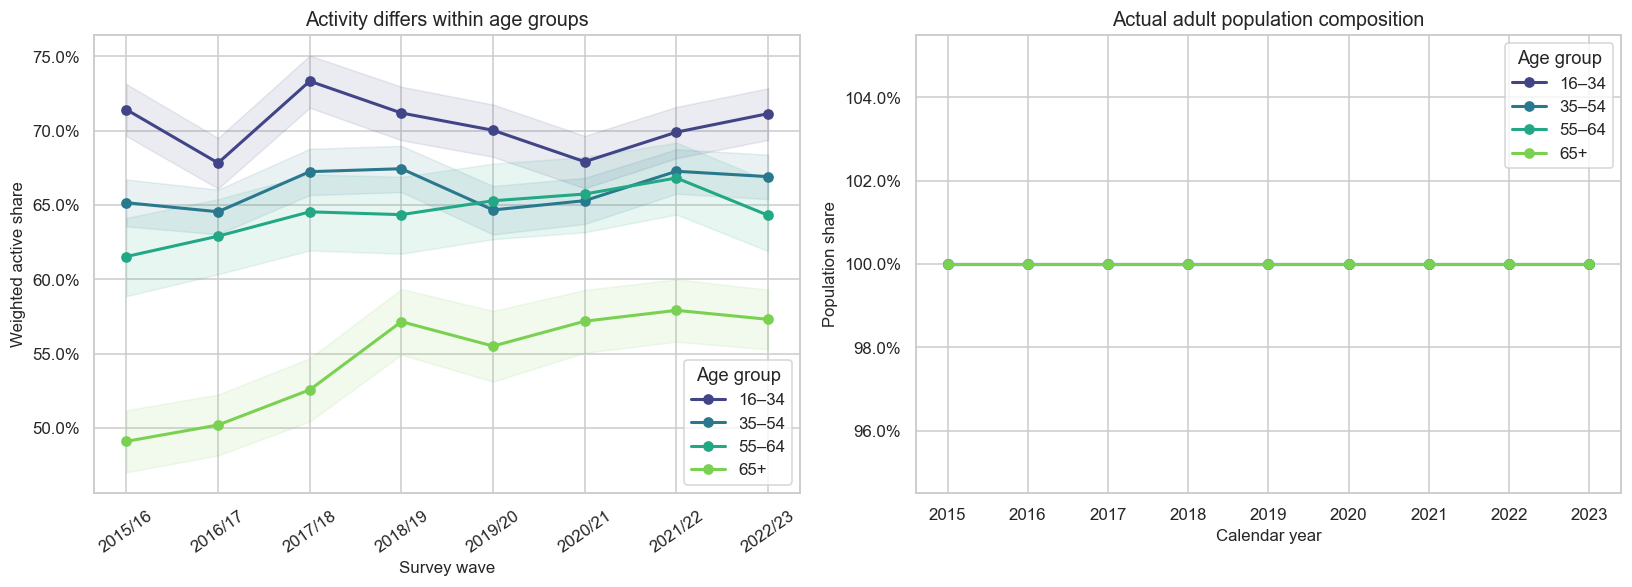

In [9]:
def wilson_interval(proportion, effective_n, z=1.96):
    p = np.asarray(proportion, dtype=float)
    n = np.asarray(effective_n, dtype=float)
    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denominator
    radius = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominator
    return np.clip(centre - radius, 0, 1), np.clip(centre + radius, 0, 1)


fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
palette = dict(zip(AGE_BANDS, sns.color_palette('viridis', len(AGE_BANDS))))
for age_band, group in age_london_annual.groupby('age_band', observed=True, sort=False):
    group = group.sort_values('year')
    low, high = wilson_interval(group['active_rate'], group['effective_n'])
    axes[0].plot(
        group['survey_wave'],
        100 * group['active_rate'],
        marker='o',
        linewidth=2,
        color=palette[age_band],
        label=age_band,
    )
    axes[0].fill_between(
        np.arange(len(group)), 100 * low, 100 * high, color=palette[age_band], alpha=0.10
    )
for age_band, group in population_age.groupby('age_band', observed=True, sort=False):
    london_group = group.groupby('calendar_year', as_index=False)['population'].sum()
    london_group['share'] = london_group['population'] / london_group.groupby('calendar_year')[
        'population'
    ].transform('sum')
    axes[1].plot(
        london_group['calendar_year'],
        100 * london_group['share'],
        marker='o',
        linewidth=2,
        color=palette[age_band],
        label=age_band,
    )
axes[0].set(
    title='Activity differs within age groups',
    xlabel='Survey wave',
    ylabel='Weighted active share',
)
axes[0].yaxis.set_major_formatter(PercentFormatter(100))
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Age group')
axes[1].set(
    title='Actual adult population composition', xlabel='Calendar year', ylabel='Population share'
)
axes[1].yaxis.set_major_formatter(PercentFormatter(100))
axes[1].legend(title='Age group')
plt.tight_layout()
plt.show()


### Findings

All **1,024 borough × year × age-group cells** are estimable. Only **0.4%** have
`effective_n < 20`; median effective sample sizes range from about 46 to 118 across age groups.
Age-stratified annual analysis is therefore feasible when its precision remains visible.


## 4. Same time, different boroughs

Continuous predictors are centred and standardised within survey year. Coefficients therefore
compare boroughs in the same year and represent percentage-point active-share differences per one
within-year standard deviation. The ladder adds demographic, income/employment, migration and
selected-crime blocks; all models retain year and Inner/Outer indicators, use `effective_n`
weights and cluster standard errors by borough.


In [10]:
CROSS_SECTION_FEATURES = {
    # One age coordinate and one crime index avoid unstable coefficients from
    # putting compositional or highly correlated variables in the same model.
    'Population composition': ['population_age_65_plus_rate'],
    'Income and employment': ['earnings_relative_to_london', 'economic_inactivity_rate'],
    'Migration': ['net_migration_per_1000'],
    'Recorded crime environment': [SELECTED_CRIME_FEATURE],
}
cross_features = sum(CROSS_SECTION_FEATURES.values(), [])
cross_section = context_annual.copy()
cross_section['active_pct'] = 100 * cross_section['active_rate']
z_features = []
for feature in cross_features:
    z_name = f'z_{feature}'
    year_mean = cross_section.groupby('year')[feature].transform('mean')
    year_sd = cross_section.groupby('year')[feature].transform('std')
    assert year_sd.gt(0).all()
    cross_section[z_name] = (cross_section[feature] - year_mean) / year_sd
    z_features.append(z_name)

base_terms = 'C(year) + C(inner_outer)'


### Nested model ladder

Predictor blocks enter in a declared order so changes in fit and coefficient behaviour remain visible.


In [11]:
model_ladder_specs = [
    ('Time + Inner/Outer only', []),
    ('Add population composition', CROSS_SECTION_FEATURES['Population composition']),
    (
        'Add income, employment and migration',
        CROSS_SECTION_FEATURES['Population composition']
        + CROSS_SECTION_FEATURES['Income and employment']
        + CROSS_SECTION_FEATURES['Migration'],
    ),
    ('Add selected recorded crime', cross_features),
]
cross_models = {}
ladder_rows = []
for model_name, raw_features in model_ladder_specs:
    terms = [f'z_{feature}' for feature in raw_features]
    formula = 'active_pct ~ ' + base_terms + ((' + ' + ' + '.join(terms)) if terms else '')
    fitted = smf.wls(formula, data=cross_section, weights=cross_section['effective_n']).fit(
        cov_type='cluster', cov_kwds={'groups': cross_section['geography_code']}
    )
    cross_models[model_name] = fitted
    prediction = fitted.predict(cross_section)
    weighted_rmse = np.sqrt(
        np.average(
            np.square(cross_section['active_pct'] - prediction),
            weights=cross_section['effective_n'],
        )
    )
    ladder_rows.append(
        {
            'model': model_name,
            'predictors beyond fixed effects': len(raw_features),
            'weighted R2': fitted.rsquared,
            'adjusted R2': fitted.rsquared_adj,
            'weighted RMSE (pp)': weighted_rmse,
            'AIC': fitted.aic,
        }
    )
cross_model_ladder = pd.DataFrame(ladder_rows)
full_cross_model = cross_models['Add selected recorded crime']


### Full-model coefficients and collinearity

The final model is translated to percentage-point effects and accompanied by VIF diagnostics.


In [12]:
coefficient_rows = []
for feature in cross_features:
    parameter = f'z_{feature}'
    coefficient_rows.append(
        {
            'feature': feature,
            'block': next(
                block for block, members in CROSS_SECTION_FEATURES.items() if feature in members
            ),
            'coefficient_pp_per_within_year_sd': full_cross_model.params[parameter],
            'ci_low': full_cross_model.conf_int().loc[parameter, 0],
            'ci_high': full_cross_model.conf_int().loc[parameter, 1],
            'p_value': full_cross_model.pvalues[parameter],
        }
    )
cross_coefficients = pd.DataFrame(coefficient_rows).sort_values(
    'coefficient_pp_per_within_year_sd'
)

vif_matrix = sm.add_constant(cross_section[z_features])
cross_vif = (
    pd.DataFrame(
        {
            'feature': vif_matrix.columns,
            'VIF': [
                variance_inflation_factor(vif_matrix.to_numpy(), index)
                for index in range(vif_matrix.shape[1])
            ],
        }
    )
    .query("feature != 'const'")
    .sort_values('VIF', ascending=False)
)

cross_model_ladder.to_csv(
    OUTPUT_DIR / 'same_time_borough_model_ladder.csv', index=False, encoding='utf-8-sig'
)
cross_coefficients.to_csv(
    OUTPUT_DIR / 'same_time_borough_coefficients.csv', index=False, encoding='utf-8-sig'
)
cross_vif.to_csv(OUTPUT_DIR / 'same_time_borough_vif.csv', index=False, encoding='utf-8-sig')
display(
    cross_model_ladder.style.format(
        {
            'weighted R2': '{:.3f}',
            'adjusted R2': '{:.3f}',
            'weighted RMSE (pp)': '{:.2f}',
            'AIC': '{:.1f}',
        }
    )
)
display(cross_vif.style.format({'VIF': '{:.2f}'}))


,model,predictors beyond fixed effects,weighted R2,adjusted R2,weighted RMSE (pp),AIC
0,Time + Inner/Outer only,0,0.272,0.249,5.08,1580.5
1,Add population composition,1,0.357,0.333,4.77,1551.0
2,"Add income, employment and migration",4,0.586,0.566,3.83,1443.9
3,Add selected recorded crime,5,0.594,0.573,3.79,1440.9


,feature,VIF
5,z_selected_recorded_crime_rate_per_1000,1.66
2,z_earnings_relative_to_london,1.33
3,z_economic_inactivity_rate,1.25
1,z_population_age_65_plus_rate,1.13
4,z_net_migration_per_1000,1.01


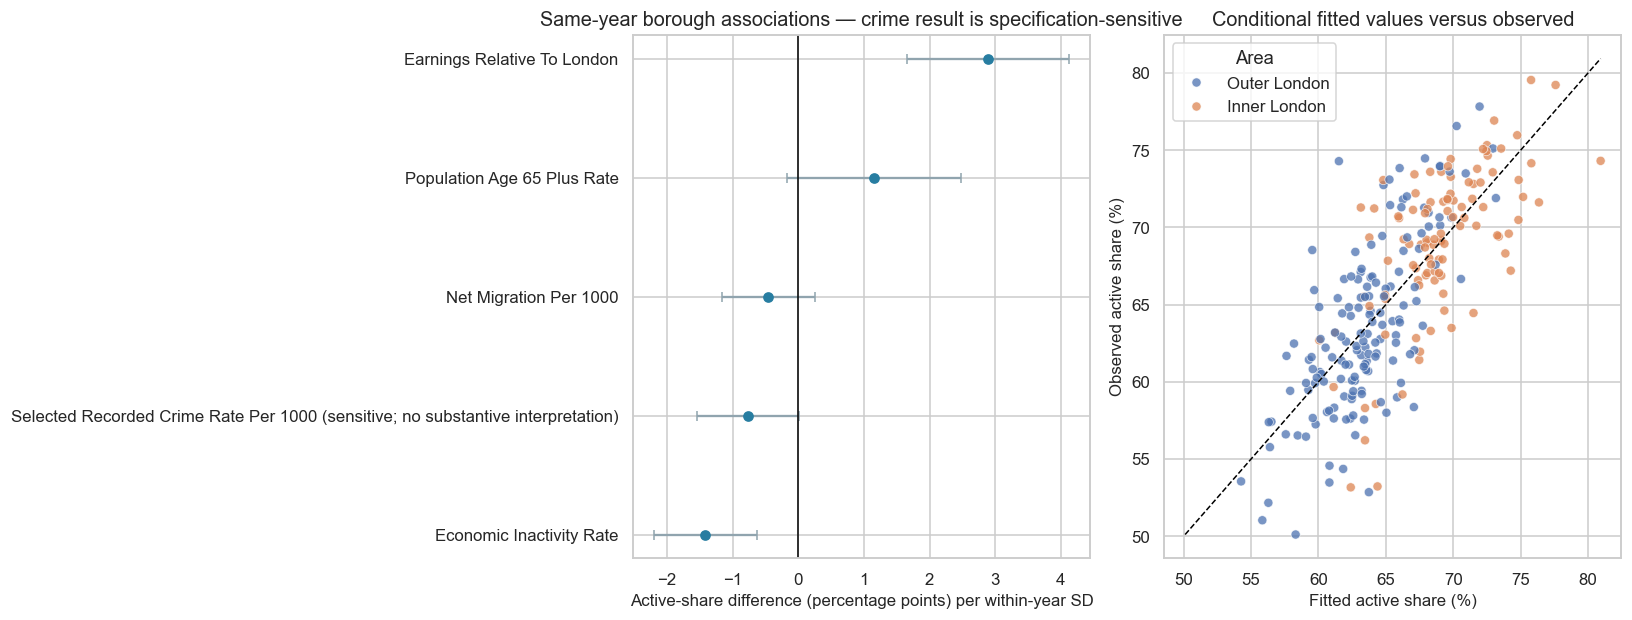

,feature,minimum,maximum,median,positive_share
0,earnings_relative_to_london,2.78,3.05,2.87,100%
1,economic_inactivity_rate,-1.54,-1.25,-1.44,0%
2,net_migration_per_1000,-0.65,-0.20,-0.46,0%
3,population_age_65_plus_rate,0.76,1.32,1.19,100%
4,selected_recorded_crime_rate_per_1000,-0.94,-0.65,-0.74,0%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
plot_coefficients = cross_coefficients.copy()
positions = np.arange(len(plot_coefficients))
plot_coefficient_labels = plot_coefficients['feature'].str.replace('_', ' ').str.title()
plot_coefficient_labels = np.where(
    plot_coefficients['feature'].eq(SELECTED_CRIME_FEATURE),
    plot_coefficient_labels + ' (sensitive; no substantive interpretation)',
    plot_coefficient_labels,
)
axes[0].errorbar(
    plot_coefficients['coefficient_pp_per_within_year_sd'],
    positions,
    xerr=[
        plot_coefficients['coefficient_pp_per_within_year_sd'] - plot_coefficients['ci_low'],
        plot_coefficients['ci_high'] - plot_coefficients['coefficient_pp_per_within_year_sd'],
    ],
    fmt='o',
    color='#277da1',
    ecolor='#90a4ae',
    capsize=3,
)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_yticks(positions, plot_coefficient_labels)
axes[0].set(
    title='Same-year borough associations — crime result is specification-sensitive',
    xlabel='Active-share difference (percentage points) per within-year SD',
    ylabel='',
)

cross_section['fitted_active_pct'] = full_cross_model.predict(cross_section)
sns.scatterplot(
    data=cross_section,
    x='fitted_active_pct',
    y='active_pct',
    hue='inner_outer',
    alpha=0.75,
    ax=axes[1],
)
limits = [
    min(cross_section['fitted_active_pct'].min(), cross_section['active_pct'].min()),
    max(cross_section['fitted_active_pct'].max(), cross_section['active_pct'].max()),
]
axes[1].plot(limits, limits, linestyle='--', color='black', linewidth=1)
axes[1].set(
    title='Conditional fitted values versus observed',
    xlabel='Fitted active share (%)',
    ylabel='Observed active share (%)',
)
axes[1].legend(title='Area')
plt.tight_layout()
plt.show()

# Leave one survey year out and refit to expose coefficient instability.
stability_rows = []
full_formula = 'active_pct ~ ' + base_terms + ' + ' + ' + '.join(z_features)
for omitted_year in sorted(cross_section['year'].unique()):
    subset = cross_section.loc[cross_section['year'].ne(omitted_year)]
    fitted = smf.wls(full_formula, data=subset, weights=subset['effective_n']).fit()
    for feature in cross_features:
        stability_rows.append(
            {
                'omitted_year': omitted_year,
                'feature': feature,
                'coefficient': fitted.params[f'z_{feature}'],
            }
        )
cross_stability = pd.DataFrame(stability_rows)
cross_stability_summary = cross_stability.groupby('feature', as_index=False).agg(
    minimum=('coefficient', 'min'),
    maximum=('coefficient', 'max'),
    median=('coefficient', 'median'),
    positive_share=('coefficient', lambda values: values.gt(0).mean()),
)
cross_stability.to_csv(
    OUTPUT_DIR / 'same_time_borough_leave_year_out_coefficients.csv',
    index=False,
    encoding='utf-8-sig',
)
display(
    cross_stability_summary.style.format(
        {
            'minimum': '{:.2f}',
            'maximum': '{:.2f}',
            'median': '{:.2f}',
            'positive_share': '{:.0%}',
        }
    )
)


### Findings

In the full same-year comparison, relative earnings has the largest association: **+2.89 pp** in
active share per within-year SD (wild-bootstrap p=0.001). Economic inactivity is **−1.41 pp**
(p=0.017). Age 65+, migration and selected crime do not pass the wild-bootstrap sensitivity.
Selected crime is especially unstable and is not treated as a substantive borough difference.


## 5. Exact algebraic decomposition of the reconstructed age-group-weighted active rate

For start year 0 and end year 1, the age-group reconstruction is
\(A_t^{recon}=\sum_g p_{gt}r_{gt}\), where \(p\) is the ONS adult population share and \(r\)
is the survey-weighted active rate for age group \(g\). The following identity is exact **for
this reconstruction**:

\[
\Delta A^{recon} = \sum_g (p_{g1}-p_{g0})\frac{r_{g1}+r_{g0}}{2}
+ \sum_g (r_{g1}-r_{g0})\frac{p_{g1}+p_{g0}}{2}.
\]

The first term is the **age-composition component** and the second the **within-age-rate
component**. This identity need not equal the change in the separately published overall survey
rate; their borough-level gap is reported explicitly. Approximate simulation intervals sample
each age-specific survey rate from a Beta distribution using Kish `effective_n`, treat population
estimates as fixed, and do not reproduce the full complex-sample variance or dependence across
survey years.


In [14]:
def symmetric_age_decomposition(start, end):
    start = start.set_index('age_band').reindex(AGE_BANDS)
    end = end.set_index('age_band').reindex(AGE_BANDS)
    p0, p1 = start['population_share'].to_numpy(float), end['population_share'].to_numpy(float)
    r0, r1 = start['active_rate'].to_numpy(float), end['active_rate'].to_numpy(float)
    composition_by_age = (p1 - p0) * (r1 + r0) / 2
    behaviour_by_age = (r1 - r0) * (p1 + p0) / 2
    return {
        'reconstructed_start': np.sum(p0 * r0),
        'reconstructed_end': np.sum(p1 * r1),
        'composition_effect': composition_by_age.sum(),
        'within_age_behaviour_effect': behaviour_by_age.sum(),
        **{f'composition_{age}': value for age, value in zip(AGE_BANDS, composition_by_age)},
        **{f'behaviour_{age}': value for age, value in zip(AGE_BANDS, behaviour_by_age)},
    }


### Borough endpoint decomposition

The identity is evaluated for every borough from Year 1 to Year 8, with approximate simulation intervals.


In [15]:
decomposition_rows = []
rng = np.random.default_rng(RANDOM_STATE)
for (code_value, name_value), group in age_borough_annual.groupby(
    ['geography_code', 'geography_name'], sort=True
):
    start = group.loc[group['year'].eq(1)].copy()
    end = group.loc[group['year'].eq(8)].copy()
    result = symmetric_age_decomposition(start, end)

    # Approximate survey-rate uncertainty; ONS population shares are fixed.
    s = start.set_index('age_band').reindex(AGE_BANDS)
    e = end.set_index('age_band').reindex(AGE_BANDS)
    draws = 2500
    r0_draw = np.vstack(
        [
            rng.beta(
                row['active_rate'] * row['effective_n'] + 0.5,
                (1 - row['active_rate']) * row['effective_n'] + 0.5,
                draws,
            )
            for _, row in s.iterrows()
        ]
    )
    r1_draw = np.vstack(
        [
            rng.beta(
                row['active_rate'] * row['effective_n'] + 0.5,
                (1 - row['active_rate']) * row['effective_n'] + 0.5,
                draws,
            )
            for _, row in e.iterrows()
        ]
    )
    p0 = s['population_share'].to_numpy(float)[:, None]
    p1 = e['population_share'].to_numpy(float)[:, None]
    comp_draw = ((p1 - p0) * (r1_draw + r0_draw) / 2).sum(axis=0)
    behaviour_draw = ((r1_draw - r0_draw) * (p1 + p0) / 2).sum(axis=0)
    result.update(
        {
            'geography_code': code_value,
            'geography_name': name_value,
            'composition_simulation_low': np.quantile(comp_draw, 0.025),
            'composition_simulation_high': np.quantile(comp_draw, 0.975),
            'behaviour_simulation_low': np.quantile(behaviour_draw, 0.025),
            'behaviour_simulation_high': np.quantile(behaviour_draw, 0.975),
        }
    )
    decomposition_rows.append(result)
age_decomposition = pd.DataFrame(decomposition_rows)
age_decomposition['reconstructed_change'] = (
    age_decomposition['reconstructed_end'] - age_decomposition['reconstructed_start']
)
age_decomposition['identity_error'] = (
    age_decomposition['reconstructed_change']
    - age_decomposition['composition_effect']
    - age_decomposition['within_age_behaviour_effect']
)
observed_endpoint = borough_annual.pivot(
    index=['geography_code', 'geography_name'], columns='year', values='active_rate'
).reset_index()
observed_endpoint['observed_change'] = observed_endpoint[8] - observed_endpoint[1]
age_decomposition = age_decomposition.merge(
    observed_endpoint[['geography_code', 'observed_change']],
    on='geography_code',
    validate='one_to_one',
)
age_decomposition['survey_reconstruction_gap'] = (
    age_decomposition['observed_change'] - age_decomposition['reconstructed_change']
)
assert age_decomposition['identity_error'].abs().max() < 1e-12

# London profiles use direct survey aggregation and actual population totals.


### London endpoint and annual chain

The same identity is calculated once for the full endpoint and sequentially between adjacent years.


In [16]:
london_population_age = population_age.groupby(
    ['calendar_year', 'age_band'], observed=True, as_index=False
)['population'].sum()
london_population_age['population_share'] = london_population_age[
    'population'
] / london_population_age.groupby('calendar_year')['population'].transform('sum')
london_age_profile = age_london_annual.merge(
    london_population_age[['calendar_year', 'age_band', 'population_share']],
    on=['calendar_year', 'age_band'],
    validate='one_to_one',
)
london_endpoint_decomposition = symmetric_age_decomposition(
    london_age_profile.loc[london_age_profile['year'].eq(1)],
    london_age_profile.loc[london_age_profile['year'].eq(8)],
)

london_chain_rows = []
for end_year in range(2, 9):
    result = symmetric_age_decomposition(
        london_age_profile.loc[london_age_profile['year'].eq(end_year - 1)],
        london_age_profile.loc[london_age_profile['year'].eq(end_year)],
    )
    result.update({'start_year': end_year - 1, 'end_year': end_year})
    london_chain_rows.append(result)
london_age_chain = pd.DataFrame(london_chain_rows)
london_age_chain['cumulative_composition'] = london_age_chain['composition_effect'].cumsum()
london_age_chain['cumulative_behaviour'] = london_age_chain['within_age_behaviour_effect'].cumsum()
london_age_chain['cumulative_total'] = (
    london_age_chain['cumulative_composition'] + london_age_chain['cumulative_behaviour']
)

age_decomposition.to_csv(
    OUTPUT_DIR / 'age_decomposition_borough_year1_to_year8.csv', index=False, encoding='utf-8-sig'
)
london_age_chain.to_csv(
    OUTPUT_DIR / 'age_decomposition_london_annual_chain.csv', index=False, encoding='utf-8-sig'
)
display(
    pd.DataFrame([london_endpoint_decomposition])
    .T.rename(columns={0: 'proportion'})
    .style.format('{:.4f}')
)


,proportion
reconstructed_start,0.6487
reconstructed_end,0.6669
composition_effect,-0.0024
within_age_behaviour_effect,0.0206
composition_16–34,-0.0101
composition_35–54,-0.0085
composition_55–64,0.0118
composition_65+,0.0044
behaviour_16–34,-0.0010
behaviour_35–54,0.0063


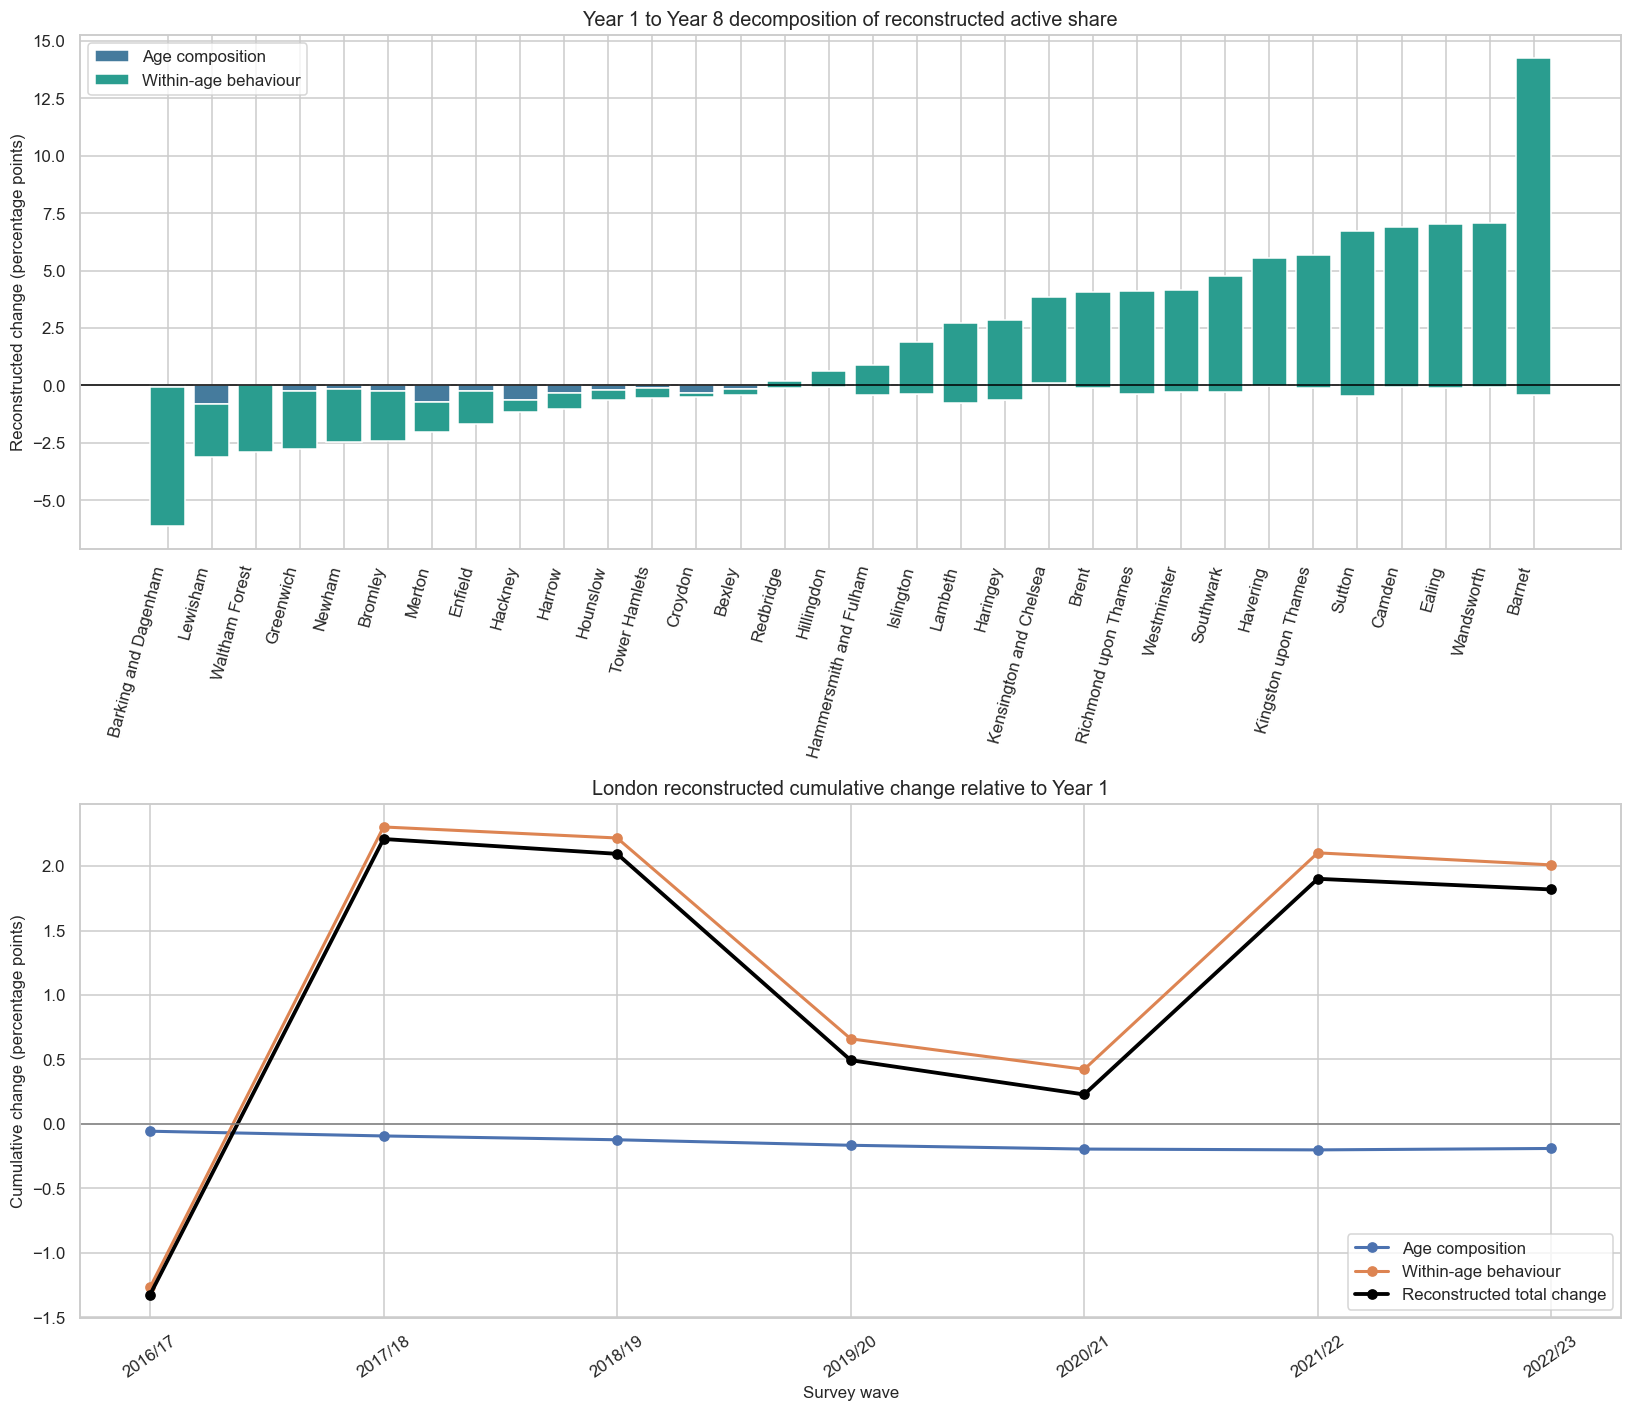

In [17]:
plot_decomposition = age_decomposition.sort_values('reconstructed_change').copy()
fig, axes = plt.subplots(2, 1, figsize=(15, 13))
positions = np.arange(len(plot_decomposition))
axes[0].bar(
    positions,
    100 * plot_decomposition['composition_effect'],
    label='Age composition',
    color='#457b9d',
)
axes[0].bar(
    positions,
    100 * plot_decomposition['within_age_behaviour_effect'],
    bottom=100 * plot_decomposition['composition_effect'],
    label='Within-age behaviour',
    color='#2a9d8f',
)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xticks(positions, plot_decomposition['geography_name'], rotation=75, ha='right')
axes[0].set(
    title='Year 1 to Year 8 decomposition of reconstructed active share',
    ylabel='Reconstructed change (percentage points)',
    xlabel='',
)
axes[0].legend()

chain_plot = pd.DataFrame(
    {
        'survey_wave': london_annual.loc[london_annual['year'].ge(2), 'survey_wave'].to_numpy(),
        'Age composition': 100 * london_age_chain['cumulative_composition'],
        'Within-age behaviour': 100 * london_age_chain['cumulative_behaviour'],
    }
)
axes[1].plot(
    chain_plot['survey_wave'],
    chain_plot['Age composition'],
    marker='o',
    linewidth=2,
    label='Age composition',
)
axes[1].plot(
    chain_plot['survey_wave'],
    chain_plot['Within-age behaviour'],
    marker='o',
    linewidth=2,
    label='Within-age behaviour',
)
axes[1].plot(
    chain_plot['survey_wave'],
    chain_plot[['Age composition', 'Within-age behaviour']].sum(axis=1),
    marker='o',
    linewidth=2.5,
    color='black',
    label='Reconstructed total change',
)
axes[1].axhline(0, color='grey', linewidth=1)
axes[1].set(
    title='London reconstructed cumulative change relative to Year 1',
    xlabel='Survey wave',
    ylabel='Cumulative change (percentage points)',
)
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend()
plt.tight_layout()
plt.show()


### Findings

For London from Year 1 to Year 8, changing age composition contributes about **−0.24 percentage
points**, while within-age rate changes contribute about **+2.06 points** to the reconstructed
active rate. The composition component is small relative to behavioural change. The median borough
gap between the published overall-rate change and reconstructed change is **0.53 points**, so the
identity is exact only for the reconstruction.


## 6. Same borough, different years: contextual attribution

This section complements the exact age decomposition with conditional regressions. Borough and
year fixed effects relate within-borough contextual change to active share; first differences and
leave-one-year-out fits test specification sensitivity. Coefficients use interpretable increments.
The common-year component may contain COVID, London-wide policy, weather, survey mode and other
shared shocks—it is **not** a policy effect.


In [18]:
trend_panel = context_annual.copy()
trend_panel['active_pct'] = 100 * trend_panel['active_rate']
trend_panel['age_16_34_per_10pp'] = trend_panel['population_age_16_34_rate'] / 0.10
trend_panel['age_65_plus_per_10pp'] = trend_panel['population_age_65_plus_rate'] / 0.10
trend_panel['earnings_relative_per_10pct'] = trend_panel['earnings_relative_to_london'] / 0.10
trend_panel['inactivity_per_10pp'] = trend_panel['economic_inactivity_rate'] / 0.10
trend_panel['migration_per_10_per_1000'] = trend_panel['net_migration_per_1000'] / 10
trend_panel['personal_safety_crime_per_10'] = (
    trend_panel['personal_safety_crime_rate_per_1000'] / 10
)
trend_panel['property_crime_per_10'] = (
    trend_panel['property_public_space_crime_rate_per_1000'] / 10
)
trend_panel['selected_crime_per_10'] = trend_panel[SELECTED_CRIME_FEATURE] / 10

TREND_GROUPS = {
    'Demographic structure': ['age_65_plus_per_10pp'],
    'Income and employment': ['earnings_relative_per_10pct', 'inactivity_per_10pp'],
    'Migration': ['migration_per_10_per_1000'],
    'Selected recorded crime environment': ['selected_crime_per_10'],
}
trend_features = sum(TREND_GROUPS.values(), [])


### Fixed-effects model

Permanent borough differences and common year shocks are absorbed before interpreting contextual coefficients.


In [19]:
trend_formula = 'active_pct ~ ' + ' + '.join(trend_features) + ' + C(geography_code) + C(year)'
trend_model = smf.wls(trend_formula, data=trend_panel, weights=trend_panel['effective_n']).fit(
    cov_type='cluster', cov_kwds={'groups': trend_panel['geography_code']}
)

trend_coefficient_rows = []
for feature in trend_features:
    trend_coefficient_rows.append(
        {
            'feature': feature,
            'group': next(group for group, members in TREND_GROUPS.items() if feature in members),
            'coefficient_pp': trend_model.params[feature],
            'ci_low': trend_model.conf_int().loc[feature, 0],
            'ci_high': trend_model.conf_int().loc[feature, 1],
            'p_value': trend_model.pvalues[feature],
        }
    )
trend_coefficients = pd.DataFrame(trend_coefficient_rows)


### Year 1→Year 8 fitted-change attribution

The fitted change is grouped into demographic, income/employment, migration, selected crime, common year and residual components.


In [20]:
endpoint_rows = []
common_year_change = trend_model.params.get('C(year)[T.8]', 0.0)
for (code_value, name_value), group in trend_panel.groupby(
    ['geography_code', 'geography_name'], sort=True
):
    start = group.loc[group['year'].eq(1)].iloc[0]
    end = group.loc[group['year'].eq(8)].iloc[0]
    feature_contributions = {
        feature: trend_model.params[feature] * (end[feature] - start[feature])
        for feature in trend_features
    }
    row = {
        'geography_code': code_value,
        'geography_name': name_value,
        'observed_change_pp': end['active_pct'] - start['active_pct'],
        'common_year_component_pp': common_year_change,
    }
    for group_name, features in TREND_GROUPS.items():
        safe_name = group_name.lower().replace(' ', '_')
        row[f'{safe_name}_pp'] = sum(feature_contributions[feature] for feature in features)
    explained = common_year_change + sum(feature_contributions.values())
    row['model_explained_change_pp'] = explained
    row['residual_change_pp'] = row['observed_change_pp'] - explained
    endpoint_rows.append(row)
trend_attribution = pd.DataFrame(endpoint_rows)

trend_coefficients.to_csv(
    OUTPUT_DIR / 'within_borough_trend_coefficients.csv', index=False, encoding='utf-8-sig'
)
trend_attribution.to_csv(
    OUTPUT_DIR / 'within_borough_year1_to_year8_attribution.csv', index=False, encoding='utf-8-sig'
)
display(
    pd.DataFrame(
        [
            {
                'observations': int(trend_model.nobs),
                'boroughs': trend_panel['geography_code'].nunique(),
                'survey years': trend_panel['year'].nunique(),
                'weighted R2': trend_model.rsquared,
                'adjusted R2': trend_model.rsquared_adj,
                'common Year 8 versus Year 1 component (pp)': common_year_change,
            }
        ]
    ).style.format(
        {
            'weighted R2': '{:.3f}',
            'adjusted R2': '{:.3f}',
            'common Year 8 versus Year 1 component (pp)': '{:.2f}',
        }
    )
)
display(
    trend_coefficients.style.format(
        {
            'coefficient_pp': '{:.2f}',
            'ci_low': '{:.2f}',
            'ci_high': '{:.2f}',
            'p_value': '{:.3f}',
        }
    )
)


,observations,boroughs,survey years,weighted R2,adjusted R2,common Year 8 versus Year 1 component (pp)
0,256,32,8,0.810,0.771,0.18


,feature,group,coefficient_pp,ci_low,ci_high,p_value
0,age_65_plus_per_10pp,Demographic structure,14.37,-0.36,29.10,0.056
1,earnings_relative_per_10pct,Income and employment,-0.03,-1.19,1.13,0.958
2,inactivity_per_10pp,Income and employment,0.60,-0.83,2.02,0.411
3,migration_per_10_per_1000,Migration,-0.00,-0.74,0.74,0.999
4,selected_crime_per_10,Selected recorded crime environment,0.23,0.01,0.45,0.044


In [21]:
# Specification sensitivity: first differences remove permanent borough levels
# before estimation and therefore provide a useful check on the level fixed-effect model.
trend_panel = trend_panel.sort_values(['geography_code', 'year']).copy()
trend_grouped = trend_panel.groupby('geography_code', sort=False)
for feature in ['active_pct'] + trend_features:
    trend_panel[f'delta_{feature}'] = trend_grouped[feature].diff()
previous_effective_n = trend_grouped['effective_n'].shift(1)
trend_panel['difference_weight'] = 2 / (1 / trend_panel['effective_n'] + 1 / previous_effective_n)
first_difference_panel = trend_panel.dropna(subset=['delta_active_pct']).copy()
first_difference_formula = (
    'delta_active_pct ~ '
    + ' + '.join(f'delta_{feature}' for feature in trend_features)
    + ' + C(year)'
)
first_difference_model = smf.wls(
    first_difference_formula,
    data=first_difference_panel,
    weights=first_difference_panel['difference_weight'],
).fit(
    cov_type='cluster',
    cov_kwds={'groups': first_difference_panel['geography_code']},
)

trend_sensitivity_rows = []
for feature in trend_features:
    for specification, fitted, parameter in [
        ('Borough + year fixed effects', trend_model, feature),
        ('First differences + year effects', first_difference_model, f'delta_{feature}'),
    ]:
        trend_sensitivity_rows.append(
            {
                'feature': feature,
                'specification': specification,
                'coefficient_pp': fitted.params[parameter],
                'ci_low': fitted.conf_int().loc[parameter, 0],
                'ci_high': fitted.conf_int().loc[parameter, 1],
                'p_value': fitted.pvalues[parameter],
            }
        )
trend_sensitivity = pd.DataFrame(trend_sensitivity_rows)

leave_year_rows = []
for omitted_year in sorted(trend_panel['year'].unique()):
    subset = trend_panel.loc[trend_panel['year'].ne(omitted_year)]
    fitted = smf.wls(trend_formula, data=subset, weights=subset['effective_n']).fit()
    for feature in trend_features:
        leave_year_rows.append(
            {
                'omitted_year': omitted_year,
                'feature': feature,
                'coefficient_pp': fitted.params[feature],
            }
        )
trend_leave_year_out = pd.DataFrame(leave_year_rows)
trend_leave_year_summary = trend_leave_year_out.groupby('feature', as_index=False).agg(
    minimum=('coefficient_pp', 'min'),
    median=('coefficient_pp', 'median'),
    maximum=('coefficient_pp', 'max'),
    positive_share=('coefficient_pp', lambda values: values.gt(0).mean()),
)
trend_sensitivity.to_csv(
    OUTPUT_DIR / 'within_borough_trend_specification_sensitivity.csv',
    index=False,
    encoding='utf-8-sig',
)
trend_leave_year_out.to_csv(
    OUTPUT_DIR / 'within_borough_trend_leave_year_out.csv', index=False, encoding='utf-8-sig'
)
display(
    trend_sensitivity.pivot(
        index='feature', columns='specification', values=['coefficient_pp', 'p_value']
    ).style.format('{:.3f}')
)
display(
    trend_leave_year_summary.style.format(
        {
            'minimum': '{:.2f}',
            'median': '{:.2f}',
            'maximum': '{:.2f}',
            'positive_share': '{:.0%}',
        }
    )
)


,feature,minimum,median,maximum,positive_share
0,age_65_plus_per_10pp,7.89,14.37,18.12,100%
1,earnings_relative_per_10pct,-0.56,-0.04,0.54,50%
2,inactivity_per_10pp,0.03,0.64,1.14,100%
3,migration_per_10_per_1000,-0.23,0.04,0.19,50%
4,selected_crime_per_10,0.14,0.23,0.34,100%


### Small-cluster inference sensitivity

There are only 32 borough clusters. Conventional cluster-robust p-values are therefore retained
but supplemented with restricted-null wild cluster bootstrap-t p-values using borough-level
Rademacher weights. The bootstrap is a sensitivity analysis, not a remedy for survey-design or
spatial information that is absent from the prepared panel. Borderline findings are not promoted
when their interpretation changes across model specifications.


In [22]:
def restricted_wild_cluster_bootstrap_t(
    fitted, clusters, parameters, repeats=999, seed=RANDOM_STATE
):
    X = np.asarray(fitted.model.exog, dtype=float)
    y = np.asarray(fitted.model.endog, dtype=float)
    weights = np.asarray(getattr(fitted.model, 'weights', np.ones(len(y))), dtype=float)
    parameter_names = list(fitted.model.exog_names)
    clusters = np.asarray(clusters)
    unique_clusters, cluster_codes = np.unique(clusters, return_inverse=True)
    n, p = X.shape
    g = len(unique_clusters)
    xtwx_inverse = np.linalg.pinv(X.T @ (weights[:, None] * X))
    beta_unrestricted = xtwx_inverse @ (X.T @ (weights * y))
    correction = (g / (g - 1)) * ((n - 1) / (n - p))
    rng = np.random.default_rng(seed)
    rows = []

    for parameter in parameters:
        parameter_index = parameter_names.index(parameter)
        restriction_variance = xtwx_inverse[parameter_index, parameter_index]
        beta_restricted = beta_unrestricted - xtwx_inverse[:, parameter_index] * (
            beta_unrestricted[parameter_index] / restriction_variance
        )
        fitted_restricted = X @ beta_restricted
        restricted_residual = y - fitted_restricted
        observed_t = fitted.params[parameter] / np.sqrt(
            fitted.cov_params().loc[parameter, parameter]
        )
        bootstrap_t = np.empty(repeats)
        for repeat in range(repeats):
            multipliers = rng.choice([-1.0, 1.0], size=g)
            y_star = fitted_restricted + restricted_residual * multipliers[cluster_codes]
            beta_star = xtwx_inverse @ (X.T @ (weights * y_star))
            residual_star = y_star - X @ beta_star
            scores = np.vstack(
                [
                    X[cluster_codes == cluster].T
                    @ (weights[cluster_codes == cluster] * residual_star[cluster_codes == cluster])
                    for cluster in range(g)
                ]
            )
            covariance_star = correction * xtwx_inverse @ (scores.T @ scores) @ xtwx_inverse
            standard_error_star = np.sqrt(
                max(covariance_star[parameter_index, parameter_index], np.finfo(float).eps)
            )
            bootstrap_t[repeat] = beta_star[parameter_index] / standard_error_star
        rows.append(
            {
                'parameter': parameter,
                'coefficient': fitted.params[parameter],
                'cluster_robust_t': observed_t,
                'cluster_robust_p_value': fitted.pvalues[parameter],
                'wild_cluster_bootstrap_p_value': (
                    1 + np.sum(np.abs(bootstrap_t) >= abs(observed_t))
                )
                / (repeats + 1),
                'bootstrap_repeats': repeats,
                'borough_clusters': g,
            }
        )
    return pd.DataFrame(rows)


### Bootstrap the three specifications

The same restricted-null Rademacher procedure is applied to same-time, fixed-effects and first-difference models.


In [23]:
bootstrap_specs = [
    (
        'Same-time borough comparison',
        full_cross_model,
        cross_section['geography_code'].to_numpy(),
        {f'z_{feature}': feature for feature in cross_features},
    ),
    (
        'Borough + year fixed effects',
        trend_model,
        trend_panel['geography_code'].to_numpy(),
        {feature: feature for feature in trend_features},
    ),
    (
        'First differences + year effects',
        first_difference_model,
        first_difference_panel['geography_code'].to_numpy(),
        {f'delta_{feature}': feature for feature in trend_features},
    ),
]
wild_cluster_parts = []
for specification_index, (specification, fitted, clusters, parameter_map) in enumerate(
    bootstrap_specs
):
    result = restricted_wild_cluster_bootstrap_t(
        fitted,
        clusters,
        list(parameter_map),
        repeats=999,
        seed=RANDOM_STATE + 100 * specification_index,
    )
    result['specification'] = specification
    result['feature'] = result['parameter'].map(parameter_map)
    wild_cluster_parts.append(result)
wild_cluster_results = pd.concat(wild_cluster_parts, ignore_index=True)
wild_cluster_results.to_csv(
    OUTPUT_DIR / 'explanatory_wild_cluster_bootstrap.csv', index=False, encoding='utf-8-sig'
)
display(
    wild_cluster_results[
        [
            'specification',
            'feature',
            'coefficient',
            'cluster_robust_p_value',
            'wild_cluster_bootstrap_p_value',
            'bootstrap_repeats',
            'borough_clusters',
        ]
    ].style.format(
        {
            'coefficient': '{:.3f}',
            'cluster_robust_p_value': '{:.3f}',
            'wild_cluster_bootstrap_p_value': '{:.3f}',
        }
    )
)


,specification,feature,coefficient,cluster_robust_p_value,wild_cluster_bootstrap_p_value,bootstrap_repeats,borough_clusters
0,Same-time borough comparison,population_age_65_plus_rate,1.152,0.090,0.140,999,32
1,Same-time borough comparison,earnings_relative_to_london,2.891,0.000,0.001,999,32
2,Same-time borough comparison,economic_inactivity_rate,-1.415,0.000,0.017,999,32
3,Same-time borough comparison,net_migration_per_1000,-0.458,0.205,0.268,999,32
4,Same-time borough comparison,selected_recorded_crime_rate_per_1000,-0.763,0.053,0.579,999,32
5,Borough + year fixed effects,age_65_plus_per_10pp,14.368,0.056,0.076,999,32
6,Borough + year fixed effects,earnings_relative_per_10pct,-0.031,0.958,0.962,999,32
7,Borough + year fixed effects,inactivity_per_10pp,0.597,0.411,0.433,999,32
8,Borough + year fixed effects,migration_per_10_per_1000,-0.001,0.999,0.998,999,32
9,Borough + year fixed effects,selected_crime_per_10,0.227,0.044,0.044,999,32


### Crime-coefficient stability

A dedicated plot makes the sign and inference changes across specifications explicit.


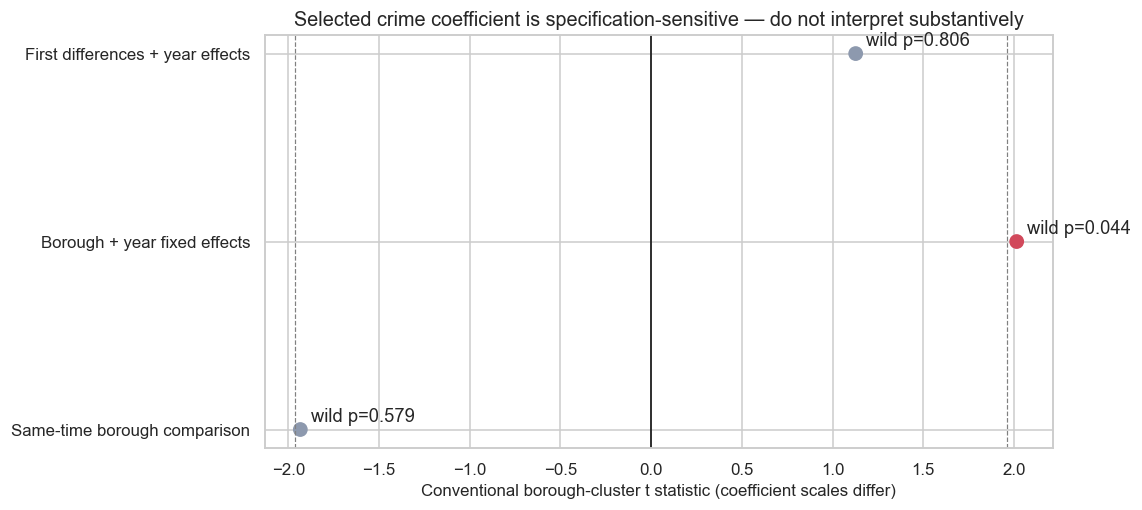

In [24]:
crime_bootstrap = wild_cluster_results.loc[
    wild_cluster_results['feature'].isin([SELECTED_CRIME_FEATURE, 'selected_crime_per_10'])
].copy()
fig, ax = plt.subplots(figsize=(10.5, 4.8))
positions = np.arange(len(crime_bootstrap))
colors = np.where(crime_bootstrap['wild_cluster_bootstrap_p_value'].lt(0.05), '#d1495b', '#8d99ae')
ax.scatter(crime_bootstrap['cluster_robust_t'], positions, s=75, c=colors)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(-1.96, color='grey', linestyle='--', linewidth=0.8)
ax.axvline(1.96, color='grey', linestyle='--', linewidth=0.8)
ax.set_yticks(positions, crime_bootstrap['specification'])
for position, (_, row) in enumerate(crime_bootstrap.iterrows()):
    ax.annotate(
        f'wild p={row["wild_cluster_bootstrap_p_value"]:.3f}',
        (row['cluster_robust_t'], position),
        xytext=(7, 5),
        textcoords='offset points',
    )
ax.set(
    title='Selected crime coefficient is specification-sensitive — do not interpret substantively',
    xlabel='Conventional borough-cluster t statistic (coefficient scales differ)',
    ylabel='',
)
plt.tight_layout()
plt.show()


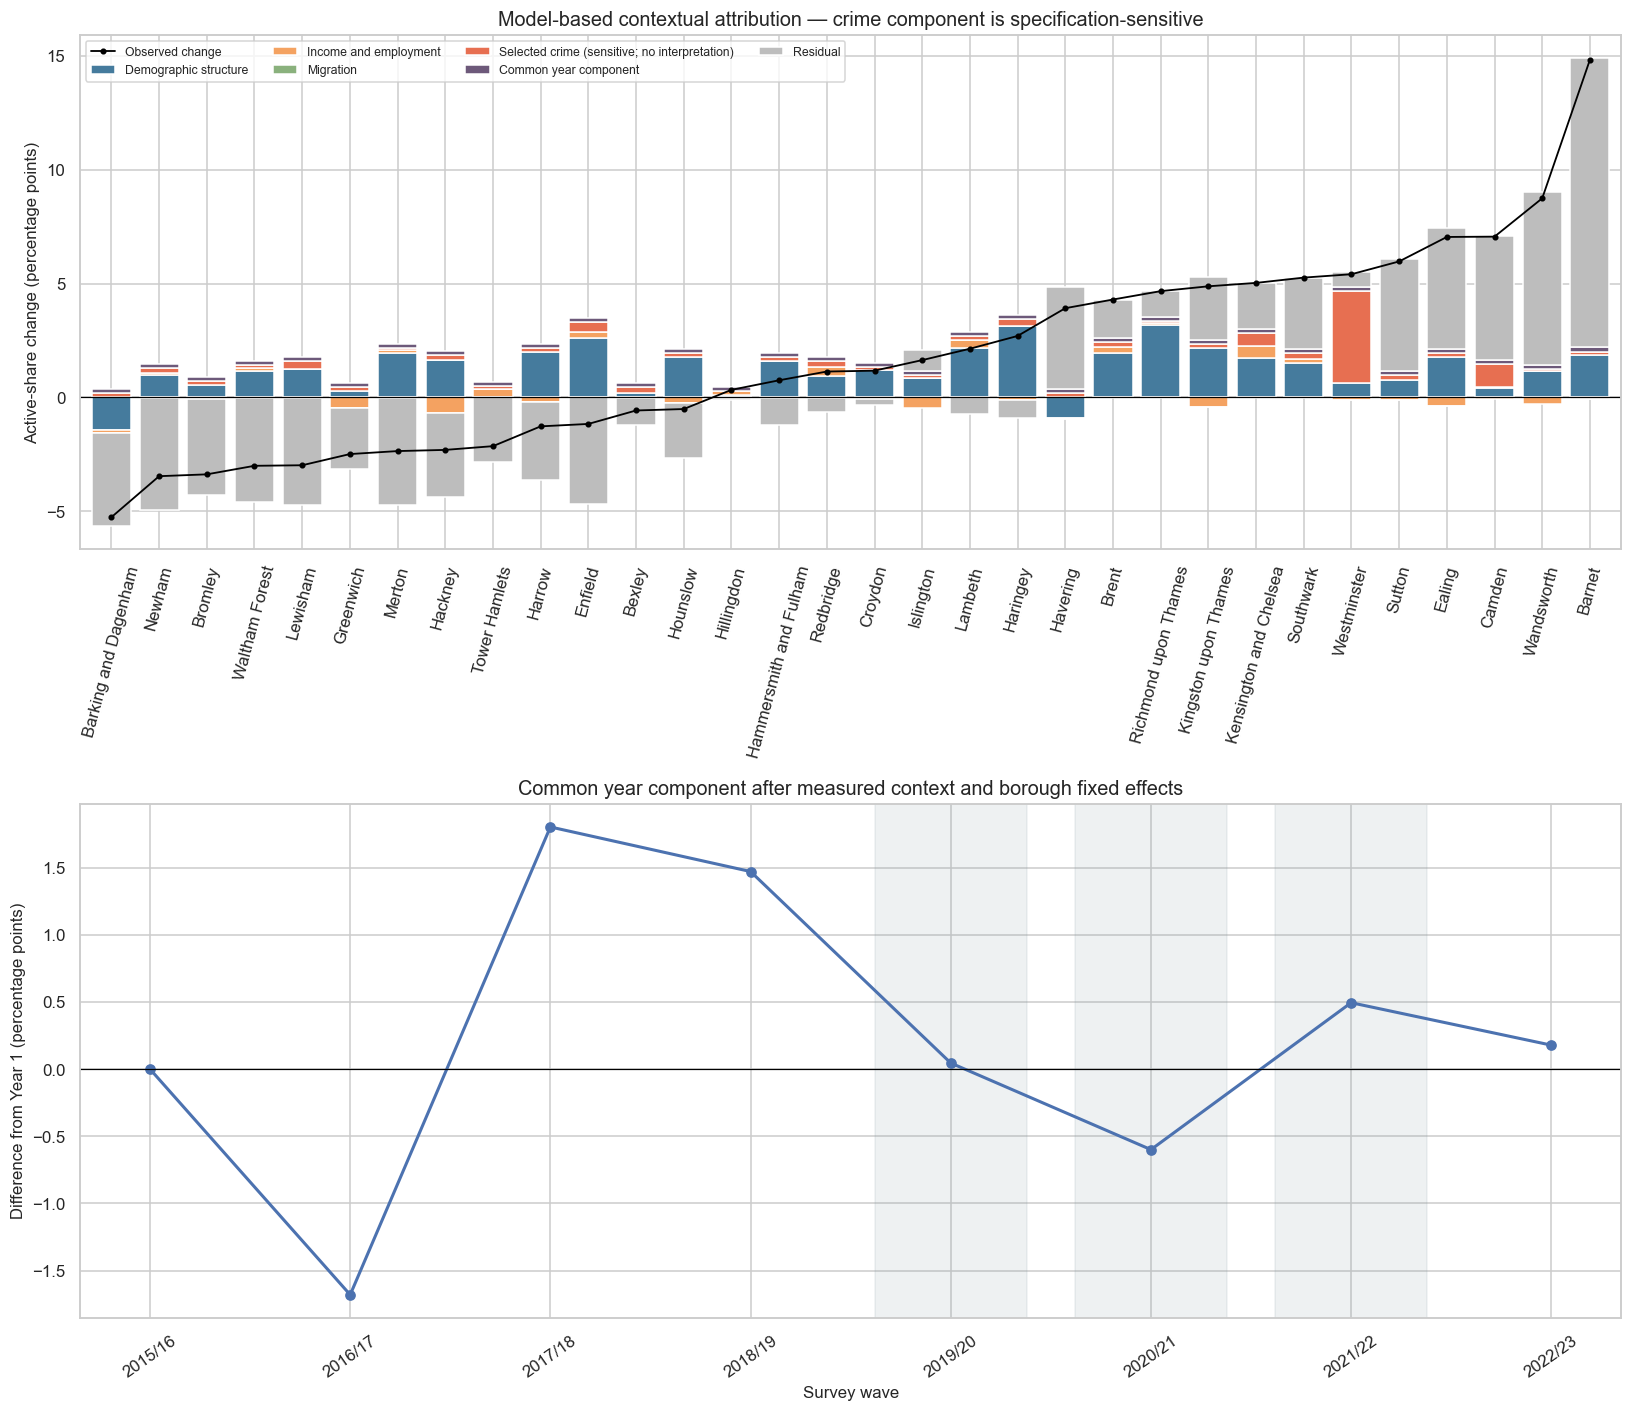

In [25]:
attribution_columns = [
    'demographic_structure_pp',
    'income_and_employment_pp',
    'migration_pp',
    'selected_recorded_crime_environment_pp',
    'common_year_component_pp',
    'residual_change_pp',
]
attribution_labels = {
    'demographic_structure_pp': 'Demographic structure',
    'income_and_employment_pp': 'Income and employment',
    'migration_pp': 'Migration',
    'selected_recorded_crime_environment_pp': 'Selected crime (sensitive; no interpretation)',
    'common_year_component_pp': 'Common year component',
    'residual_change_pp': 'Residual',
}
plot_attribution = trend_attribution.sort_values('observed_change_pp').set_index('geography_name')
fig, axes = plt.subplots(2, 1, figsize=(15, 13))
plot_attribution[attribution_columns].rename(columns=attribution_labels).plot(
    kind='bar',
    stacked=True,
    width=0.82,
    color=['#457b9d', '#f4a261', '#8ab17d', '#e76f51', '#6d597a', '#bdbdbd'],
    ax=axes[0],
)
axes[0].plot(
    np.arange(len(plot_attribution)),
    plot_attribution['observed_change_pp'],
    color='black',
    marker='o',
    linewidth=1.2,
    markersize=3,
    label='Observed change',
)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set(
    title='Model-based contextual attribution — crime component is specification-sensitive',
    xlabel='',
    ylabel='Active-share change (percentage points)',
)
axes[0].tick_params(axis='x', rotation=75)
axes[0].legend(ncol=4, fontsize=8)

year_effects = [{'year': 1, 'common_component_pp': 0.0}]
for year_value in range(2, 9):
    year_effects.append(
        {
            'year': year_value,
            'common_component_pp': trend_model.params.get(f'C(year)[T.{year_value}]', 0.0),
        }
    )
year_effects = pd.DataFrame(year_effects).merge(
    london_annual[['year', 'survey_wave']], on='year', validate='one_to_one'
)
axes[1].plot(
    year_effects['survey_wave'], year_effects['common_component_pp'], marker='o', linewidth=2
)
for position, wave in enumerate(year_effects['survey_wave']):
    if wave in {'2019/20', '2020/21', '2021/22'}:
        axes[1].axvspan(position - 0.38, position + 0.38, color='#78909c', alpha=0.12)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set(
    title='Common year component after measured context and borough fixed effects',
    xlabel='Survey wave',
    ylabel='Difference from Year 1 (percentage points)',
)
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


### Findings

No contextual coefficient is stable enough across fixed effects, first differences, leave-year-out
checks and wild bootstrap to support a causal statement. Selected crime changes from negative in
same-time comparison to positive in fixed effects, then becomes non-significant in first differences
(wild p-values **0.579, 0.044 and 0.806**). First-difference economic inactivity is positive
(wild p=0.041) but is model-dependent. The common-year component remains an unlabelled shared shock,
not a policy effect.


## 7. Prediction-model explainability

Notebook 02 selected the monthly model strictly on rolling development-period validation. This
section reconstructs that selected model, verifies its predictions against the saved holdout file,
and applies two complementary group checks on the untouched Year 8 test set:

- joint random permutation as a fitted-model stress test;
- leave-one-group-out **refitting** as the structural sensitivity that avoids evaluating wholly
  shuffled borough-time combinations.

Joint permutation preserves relationships inside each activity block, but it can still break
borough, season and time structure. Its 2.5%/97.5% repeat summaries are randomisation quantiles,
not confidence intervals. Refit ablation asks a different question because remaining predictors
can substitute after retraining. Neither method is causal, and correlated groups can substitute
for one another.


In [26]:
monthly_cv = pd.read_csv(PREDICTION_DIR / 'monthly_forecast_cv_metrics.csv')
best_cv = monthly_cv.sort_values('mean_weighted_tv').iloc[0]
one_se_limit = best_cv['mean_weighted_tv'] + best_cv['standard_error']
eligible_models = set(monthly_cv.loc[monthly_cv['mean_weighted_tv'].le(one_se_limit), 'model'])
MODEL_PRIORITY = ['Seasonal naive', 'Ridge', 'Random Forest', 'Gradient Boosting']
SELECTED_MONTHLY_MODEL = next(model for model in MODEL_PRIORITY if model in eligible_models)
assert SELECTED_MONTHLY_MODEL == 'Gradient Boosting'

selected_parameter_table = pd.read_csv(
    PREDICTION_DIR / 'monthly_forecast_selected_hyperparameters.csv'
)
selected_parameter_row = selected_parameter_table.loc[
    selected_parameter_table['model'].eq(SELECTED_MONTHLY_MODEL)
].iloc[0]
SELECTED_GB_PARAMS = {
    'n_estimators': int(selected_parameter_row['n_estimators']),
    'learning_rate': float(selected_parameter_row['learning_rate']),
    'max_depth': int(selected_parameter_row['max_depth']),
    'min_samples_leaf': int(selected_parameter_row['min_samples_leaf']),
    'loss': str(selected_parameter_row['loss']),
}


### Reconstruct the selected feature panel

Feature inclusion and final hyperparameters are read from Notebook 02 outputs; no explanatory choice can silently change the predictor.


In [27]:
activity_columns = [
    column for column in borough_monthly.columns if column.startswith(ACTIVITY_PREFIXES)
]
survey_source_columns = TARGETS + COMPOSITION_FEATURES + activity_columns
external_decisions = pd.read_csv(PREDICTION_DIR / 'monthly_forecast_external_feature_ablation.csv')
selected_external_row = external_decisions.loc[
    external_decisions['model'].eq(SELECTED_MONTHLY_MODEL)
].iloc[0]
SELECTED_MONTHLY_USE_EXTERNAL = bool(selected_external_row['external_context_retained'])
external_source_columns = FORECAST_CONTEXT_FEATURES if SELECTED_MONTHLY_USE_EXTERNAL else []
source_columns = survey_source_columns + external_source_columns
monthly_panel = (
    borough_monthly.sort_values(['geography_code', 'month_index']).reset_index(drop=True).copy()
)
grouped = monthly_panel.groupby('geography_code', sort=False)
engineered = {
    'trend': monthly_panel['month_index'].astype(float),
    'month_sin': np.sin(2 * np.pi * (monthly_panel['month_of_wave'] - 1) / 12),
    'month_cos': np.cos(2 * np.pi * (monthly_panel['month_of_wave'] - 1) / 12),
}


def covid_restriction_flag(dates):
    dates = pd.to_datetime(dates)
    return (
        ((dates >= '2020-03-01') & (dates < '2021-08-01'))
        | ((dates >= '2021-12-01') & (dates < '2022-03-01'))
    ).astype(int)


engineered['covid_restriction_flag'] = covid_restriction_flag(monthly_panel['period_start'])
engineered['covid_lag12_source_flag'] = covid_restriction_flag(
    monthly_panel['period_start'] - pd.DateOffset(years=1)
)
for column in source_columns:
    engineered[f'{column}_lag12'] = grouped[column].shift(12)
monthly_model_panel = pd.concat([monthly_panel, pd.DataFrame(engineered)], axis=1)
survey_lagged_features = [f'{column}_lag12' for column in survey_source_columns]
external_lagged_features = [f'{column}_lag12' for column in external_source_columns]
lagged_source_features = survey_lagged_features + external_lagged_features
monthly_model_panel['lag_missing_fraction'] = (
    monthly_model_panel[lagged_source_features].isna().mean(axis=1)
)
numeric_features = [
    'trend',
    'month_sin',
    'month_cos',
    'covid_restriction_flag',
    'covid_lag12_source_flag',
] + lagged_source_features
categorical_features = ['geography_name']
model_features = numeric_features + categorical_features
supervised = monthly_model_panel.loc[
    monthly_model_panel['month_index'].ge(13)
    & monthly_model_panel[TARGETS].notna().all(axis=1)
    & monthly_model_panel['lag_missing_fraction'].lt(0.95)
].copy()
development = supervised.loc[supervised['month_index'].le(84)].copy()
holdout = supervised.loc[supervised['month_index'].between(85, 96)].copy()
assert len(holdout) == 12 * 32


### Reuse the coherent-share transformation

The same ALR map and reliability weights reproduce the selected model's fitting scale.


In [28]:
def shares_to_alr(shares, epsilon=ALR_EPSILON):
    values = np.asarray(shares, dtype=float)
    values = np.clip(values, epsilon, None)
    values = values / values.sum(axis=1, keepdims=True)
    return np.column_stack(
        [
            np.log(values[:, 0] / values[:, 2]),
            np.log(values[:, 1] / values[:, 2]),
        ]
    )


def alr_to_shares(coordinates):
    coordinates = np.asarray(coordinates, dtype=float)
    logits = np.column_stack([coordinates[:, 0], coordinates[:, 1], np.zeros(len(coordinates))])
    logits -= logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)


def normalised_fit_weights(weights):
    values = np.asarray(weights, dtype=float)
    low, high = np.quantile(values, [0.05, 0.95])
    values = np.clip(values, low, high)
    return values / values.mean()


def weighted_tv(actual, predicted, weights):
    row_tv = 0.5 * np.abs(np.asarray(actual) - np.asarray(predicted)).sum(axis=1)
    return float(np.average(row_tv, weights=np.asarray(weights)))


### Refit and verify the frozen model

Predictions must match the saved Notebook 02 holdout file to numerical tolerance before any explanation is accepted.


In [29]:
numeric_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='median')),
        ('variance', VarianceThreshold(threshold=1e-10)),
    ]
)
monthly_preprocessor = ColumnTransformer(
    [
        ('numeric', numeric_pipeline, numeric_features),
        (
            'borough',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            categorical_features,
        ),
    ]
)
monthly_boost = Pipeline(
    [
        ('preprocessor', monthly_preprocessor),
        (
            'model',
            MultiOutputRegressor(
                GradientBoostingRegressor(
                    **SELECTED_GB_PARAMS,
                    random_state=RANDOM_STATE,
                ),
                n_jobs=-1,
            ),
        ),
    ]
)
monthly_boost.fit(
    development[model_features],
    shares_to_alr(development[TARGETS]),
    model__sample_weight=normalised_fit_weights(development['effective_n']),
)
holdout_prediction = alr_to_shares(monthly_boost.predict(holdout[model_features]))
actual_holdout = holdout[TARGETS].to_numpy(float)
baseline_tv = weighted_tv(actual_holdout, holdout_prediction, holdout['effective_n'])

saved_prediction = pd.read_csv(PREDICTION_DIR / 'monthly_forecast_holdout_predictions.csv')
saved_prediction = holdout[['month_index', 'geography_code']].merge(
    saved_prediction, on=['month_index', 'geography_code'], validate='one_to_one'
)
saved_columns = [f'gradient_boosting_{target}' for target in TARGETS]
maximum_reproduction_difference = np.abs(
    holdout_prediction - saved_prediction[saved_columns].to_numpy(float)
).max()
assert maximum_reproduction_difference < 1e-10


In [30]:
PREDICTOR_GROUPS = {
    'Calendar and trend': ['trend', 'month_sin', 'month_cos'],
    'COVID calendar flags': ['covid_restriction_flag', 'covid_lag12_source_flag'],
    'Lagged activity-state outcomes': [f'{target}_lag12' for target in TARGETS],
    'Lagged survey composition': [f'{feature}_lag12' for feature in COMPOSITION_FEATURES],
    'Lagged 12-month participation': [
        f'{column}_lag12' for column in activity_columns if column.startswith('MONTHS12_RATE_')
    ],
    'Lagged recent participation (any)': [
        f'{column}_lag12' for column in activity_columns if column.startswith('DAYS_ANY_RATE_')
    ],
    'Lagged recent participation (2+)': [
        f'{column}_lag12' for column in activity_columns if column.startswith('DAYS_2PLUS_RATE_')
    ],
    'Borough identity': ['geography_name'],
}
if external_lagged_features:
    PREDICTOR_GROUPS['Lagged external context'] = external_lagged_features
assert set(sum(PREDICTOR_GROUPS.values(), [])) == set(model_features)


### Held-out grouped-permutation stress test

Each block is permuted jointly across test rows over repeated seeded runs; randomisation quantiles are descriptive, not confidence intervals.


In [31]:
rng = np.random.default_rng(RANDOM_STATE)
permutation_rows = []
repeats = 30
for group_name, columns in PREDICTOR_GROUPS.items():
    for repeat in range(repeats):
        permuted = holdout[model_features].copy()
        if group_name == 'Borough identity':
            # Preserve one identity for all 12 rows of each borough.
            boroughs = np.sort(permuted['geography_name'].unique())
            mapping = dict(zip(boroughs, rng.permutation(boroughs)))
            permuted['geography_name'] = permuted['geography_name'].map(mapping)
        else:
            permutation = rng.permutation(len(permuted))
            # Move each conceptual block jointly so relationships inside the block are retained.
            permuted.loc[:, columns] = permuted[columns].to_numpy()[permutation]
        predicted = alr_to_shares(monthly_boost.predict(permuted))
        loss = weighted_tv(actual_holdout, predicted, holdout['effective_n'])
        permutation_rows.append(
            {
                'predictor_group': group_name,
                'repeat': repeat + 1,
                'permuted_weighted_tv': loss,
                'increase_in_weighted_tv': loss - baseline_tv,
            }
        )
group_permutation_raw = pd.DataFrame(permutation_rows)
group_permutation = (
    group_permutation_raw.groupby('predictor_group', as_index=False)
    .agg(
        mean_increase=('increase_in_weighted_tv', 'mean'),
        sd_increase=('increase_in_weighted_tv', 'std'),
        randomisation_q025=('increase_in_weighted_tv', lambda values: values.quantile(0.025)),
        randomisation_q975=('increase_in_weighted_tv', lambda values: values.quantile(0.975)),
        positive_share=('increase_in_weighted_tv', lambda values: values.gt(0).mean()),
    )
    .sort_values('mean_increase')
)
group_permutation['increase_relative_to_baseline'] = (
    group_permutation['mean_increase'] / baseline_tv
)
group_permutation_raw.to_csv(
    OUTPUT_DIR / 'monthly_grouped_permutation_repeats.csv', index=False, encoding='utf-8-sig'
)
group_permutation.to_csv(
    OUTPUT_DIR / 'monthly_grouped_permutation_importance.csv', index=False, encoding='utf-8-sig'
)


### Permutation summary plot

Absolute and relative TV deterioration are shown together so small effects are not overstated.


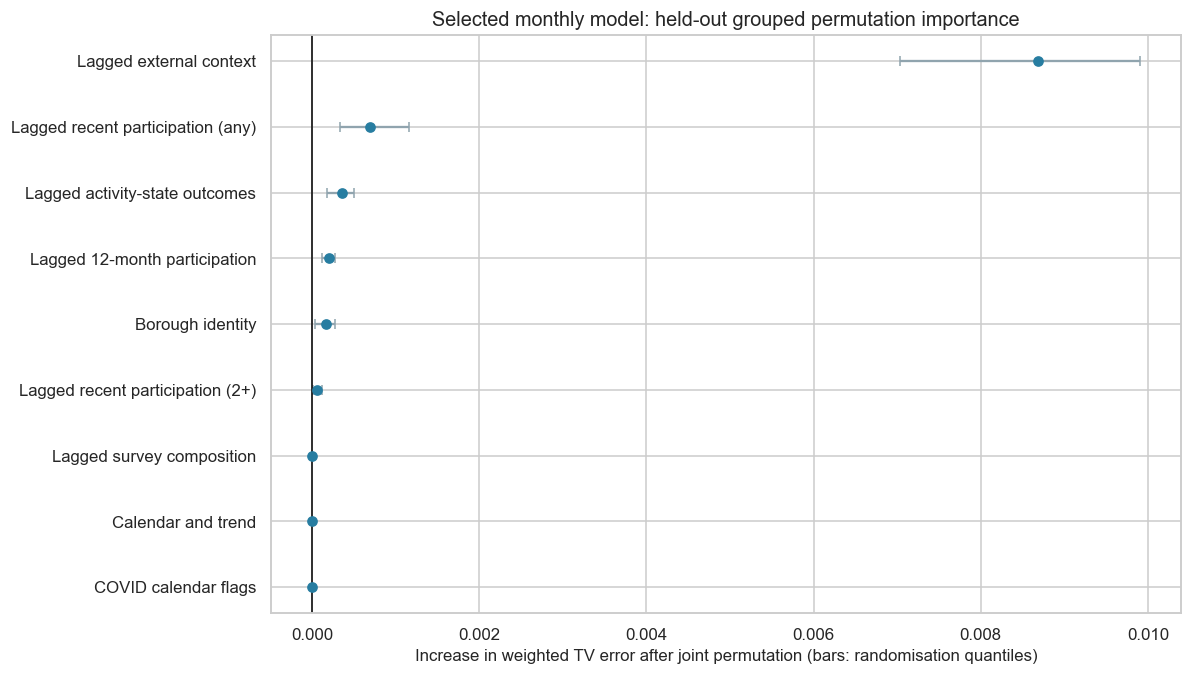

,predictor_group,mean_increase,sd_increase,randomisation_q025,randomisation_q975,positive_share,increase_relative_to_baseline
5,Lagged external context,0.0087,0.0009,0.0070,0.0099,100%,8.4%
7,Lagged recent participation (any),0.0007,0.0002,0.0003,0.0012,100%,0.7%
4,Lagged activity-state outcomes,0.0004,0.0001,0.0002,0.0005,100%,0.3%
3,Lagged 12-month participation,0.0002,0.0000,0.0001,0.0003,100%,0.2%
0,Borough identity,0.0002,0.0001,0.0000,0.0003,97%,0.2%
6,Lagged recent participation (2+),0.0001,0.0000,0.0000,0.0001,97%,0.1%
1,COVID calendar flags,0.0000,0.0000,0.0000,0.0000,0%,0.0%
2,Calendar and trend,0.0000,0.0000,0.0000,0.0000,0%,0.0%
8,Lagged survey composition,0.0000,0.0000,0.0000,0.0000,0%,0.0%


In [32]:
fig, ax = plt.subplots(figsize=(11, 6.3))
positions = np.arange(len(group_permutation))
ax.errorbar(
    group_permutation['mean_increase'],
    positions,
    xerr=[
        group_permutation['mean_increase'] - group_permutation['randomisation_q025'],
        group_permutation['randomisation_q975'] - group_permutation['mean_increase'],
    ],
    fmt='o',
    color='#277da1',
    ecolor='#90a4ae',
    capsize=3,
)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(positions, group_permutation['predictor_group'])
ax.set(
    title='Selected monthly model: held-out grouped permutation importance',
    xlabel='Increase in weighted TV error after joint permutation (bars: randomisation quantiles)',
    ylabel='',
)
plt.tight_layout()
plt.show()
display(
    group_permutation.sort_values('mean_increase', ascending=False).style.format(
        {
            'mean_increase': '{:.4f}',
            'sd_increase': '{:.4f}',
            'randomisation_q025': '{:.4f}',
            'randomisation_q975': '{:.4f}',
            'increase_relative_to_baseline': '{:.1%}',
            'positive_share': '{:.0%}',
        }
    )
)


### Leave-one-group-out refit ablation

Each predictor group is removed from the development data, the same pre-selected Gradient
Boosting specification is refitted, and Year 8 TV error is recomputed. This avoids feeding the
model globally shuffled borough-time combinations. It measures the incremental information left
after other groups are allowed to substitute, not the causal importance of the removed group.


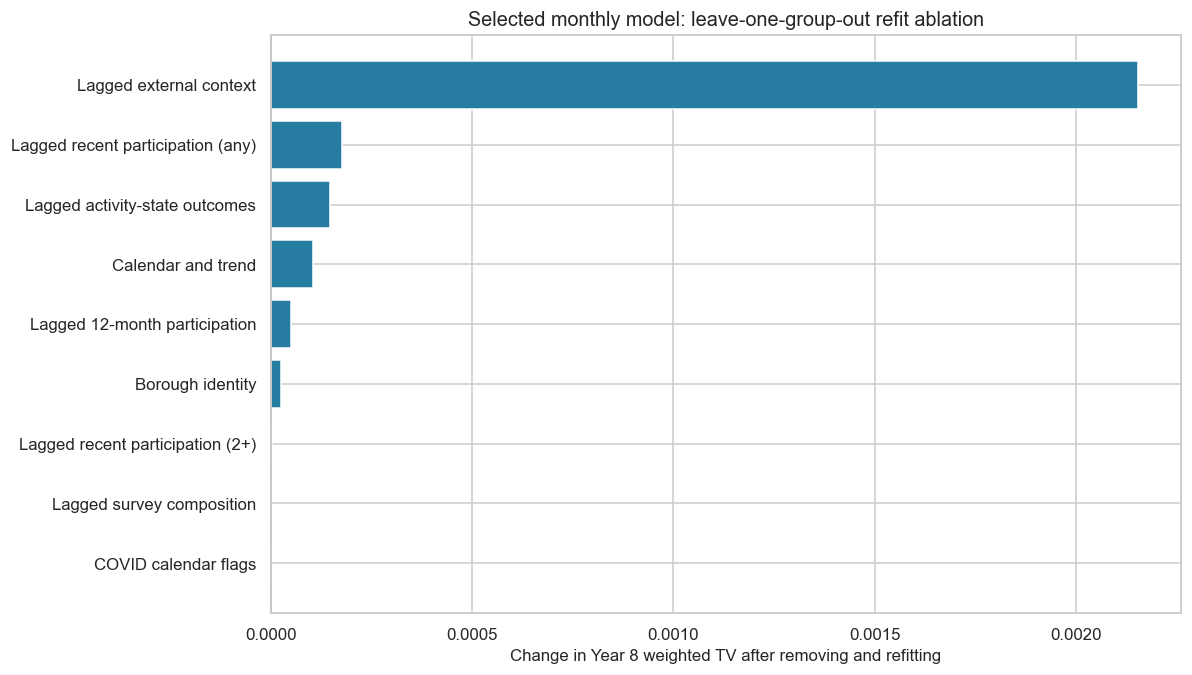

,removed_predictor_group,remaining_features,baseline_weighted_tv,ablated_refit_weighted_tv,increase_in_weighted_tv,increase_relative_to_baseline
8,Lagged external context,384,0.1031,0.1053,+0.0022,+2.1%
5,Lagged recent participation (any),270,0.1031,0.1033,+0.0002,+0.2%
2,Lagged activity-state outcomes,391,0.1031,0.1032,+0.0001,+0.1%
0,Calendar and trend,391,0.1031,0.1032,+0.0001,+0.1%
4,Lagged 12-month participation,270,0.1031,0.1032,+0.0000,+0.0%
7,Borough identity,393,0.1031,0.1031,+0.0000,+0.0%
6,Lagged recent participation (2+),270,0.1031,0.1031,+0.0000,+0.0%
1,COVID calendar flags,392,0.1031,0.1031,+0.0000,+0.0%
3,Lagged survey composition,391,0.1031,0.1031,+0.0000,+0.0%


In [33]:
def make_monthly_ablation_boost(remaining_features):
    remaining_numeric = [feature for feature in remaining_features if feature != 'geography_name']
    transformers = []
    if remaining_numeric:
        transformers.append(
            (
                'numeric',
                Pipeline(
                    [
                        ('imputer', SimpleImputer(strategy='median')),
                        ('variance', VarianceThreshold(threshold=1e-10)),
                    ]
                ),
                remaining_numeric,
            )
        )
    if 'geography_name' in remaining_features:
        transformers.append(
            (
                'borough',
                OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                ['geography_name'],
            )
        )
    preprocessor = ColumnTransformer(transformers)
    return Pipeline(
        [
            ('preprocessor', preprocessor),
            (
                'model',
                MultiOutputRegressor(
                    GradientBoostingRegressor(
                        **SELECTED_GB_PARAMS,
                        random_state=RANDOM_STATE,
                    ),
                    n_jobs=-1,
                ),
            ),
        ]
    )


refit_ablation_rows = []
for group_name, removed_features in PREDICTOR_GROUPS.items():
    remaining_features = [feature for feature in model_features if feature not in removed_features]
    ablated_model = make_monthly_ablation_boost(remaining_features)
    ablated_model.fit(
        development[remaining_features],
        shares_to_alr(development[TARGETS]),
        model__sample_weight=normalised_fit_weights(development['effective_n']),
    )
    ablated_prediction = alr_to_shares(ablated_model.predict(holdout[remaining_features]))
    ablated_tv = weighted_tv(actual_holdout, ablated_prediction, holdout['effective_n'])
    refit_ablation_rows.append(
        {
            'removed_predictor_group': group_name,
            'remaining_features': len(remaining_features),
            'baseline_weighted_tv': baseline_tv,
            'ablated_refit_weighted_tv': ablated_tv,
            'increase_in_weighted_tv': ablated_tv - baseline_tv,
            'increase_relative_to_baseline': (ablated_tv - baseline_tv) / baseline_tv,
        }
    )
refit_group_ablation = pd.DataFrame(refit_ablation_rows).sort_values('increase_in_weighted_tv')
refit_group_ablation.to_csv(
    OUTPUT_DIR / 'monthly_refit_group_ablation.csv', index=False, encoding='utf-8-sig'
)
fig, ax = plt.subplots(figsize=(11, 6.3))
colors = np.where(refit_group_ablation['increase_in_weighted_tv'].ge(0), '#277da1', '#8d99ae')
ax.barh(
    refit_group_ablation['removed_predictor_group'],
    refit_group_ablation['increase_in_weighted_tv'],
    color=colors,
)
ax.axvline(0, color='black', linewidth=1)
ax.set(
    title='Selected monthly model: leave-one-group-out refit ablation',
    xlabel='Change in Year 8 weighted TV after removing and refitting',
    ylabel='',
)
plt.tight_layout()
plt.show()
display(
    refit_group_ablation.sort_values('increase_in_weighted_tv', ascending=False).style.format(
        {
            'baseline_weighted_tv': '{:.4f}',
            'ablated_refit_weighted_tv': '{:.4f}',
            'increase_in_weighted_tv': '{:+.4f}',
            'increase_relative_to_baseline': '{:+.1%}',
        }
    )
)


### Method decision: refit ablation, grouped permutation and TreeSHAP

No single explanation method answers every question. Leave-one-group-out refitting is the primary structural sensitivity, while held-out grouped
permutation remains a fitted-model **stress test** because it measures the change in final three-share TV
error. TreeSHAP is added for **directional and local** explanation of the selected Gradient
Boosting model. PDP/ICE are not used as the main method because independently varying one of 372
correlated activity inputs can create unrealistic combinations; LIME is not used because its local
sampling and kernel choices add avoidable instability.

The fitted model predicts two ALR coordinates. TreeSHAP therefore explains
`log(inactive / active)` and `log(fairly active / active)` exactly on the raw tree-output scale.
These values must not be described directly as percentage-point effects on active share. The
nonlinear ALR inverse jointly converts both coordinates into the three coherent shares.

The permutation repeat ranges are randomisation quantiles, not confidence intervals. Every importance increase is also reported relative to the baseline TV error so that small absolute changes are not overstated.


In [34]:
import shap
from scipy.stats import spearmanr

SHAP_OUTPUT_LABELS = {
    'inactive_vs_active': 'log(Inactive / Active)',
    'fairly_vs_active': 'log(Fairly active / Active)',
}


def stratified_background(frame, rows_per_borough):
    parts = []
    for _, group in frame.groupby('geography_code', sort=True):
        group = group.sort_values('month_index')
        positions = np.linspace(0, len(group) - 1, rows_per_borough).round().astype(int)
        parts.append(group.iloc[np.unique(positions)])
    result = pd.concat(parts).sort_values(['geography_code', 'month_index'])
    assert len(result) == 32 * rows_per_borough
    return result


preprocessor = monthly_boost.named_steps['preprocessor']
tree_estimators = monthly_boost.named_steps['model'].estimators_
transformed_feature_names = preprocessor.get_feature_names_out().tolist()
X_holdout_transformed = preprocessor.transform(holdout[model_features])
background_128 = stratified_background(development, rows_per_borough=4)
X_background_128 = preprocessor.transform(background_128[model_features])
assert X_holdout_transformed.shape[1] == len(transformed_feature_names)

# Map post-preprocessing fields back to the same conceptual blocks used by permutation.
raw_feature_to_group = {
    raw_feature: group_name
    for group_name, raw_features in PREDICTOR_GROUPS.items()
    for raw_feature in raw_features
}
transformed_feature_groups = []
friendly_feature_names = []
for transformed_name in transformed_feature_names:
    if transformed_name.startswith('numeric__'):
        raw_name = transformed_name.removeprefix('numeric__')
        group_name = raw_feature_to_group[raw_name]
        friendly_name = raw_name.removesuffix('_lag12').replace('_', ' ').title()
    elif transformed_name.startswith('borough__geography_name_'):
        group_name = 'Borough identity'
        friendly_name = transformed_name.removeprefix('borough__geography_name_')
    else:
        raise ValueError(f'Unmapped transformed feature: {transformed_name}')
    transformed_feature_groups.append(group_name)
    friendly_feature_names.append(friendly_name)

transformed_feature_groups = np.asarray(transformed_feature_groups)
tree_shap_explanations = {}
shap_additivity_rows = []
for output_index, (output_name, output_label) in enumerate(SHAP_OUTPUT_LABELS.items()):
    explainer = shap.TreeExplainer(
        tree_estimators[output_index],
        data=X_background_128,
        feature_perturbation='interventional',
        model_output='raw',
        feature_names=transformed_feature_names,
    )
    explanation = explainer(X_holdout_transformed, check_additivity=True)
    predicted_raw = tree_estimators[output_index].predict(X_holdout_transformed)
    reconstructed_raw = explanation.base_values + explanation.values.sum(axis=1)
    maximum_error = np.max(np.abs(predicted_raw - reconstructed_raw))
    assert maximum_error < 1e-7
    tree_shap_explanations[output_name] = explanation
    shap_additivity_rows.append(
        {
            'output': output_name,
            'output_scale': output_label,
            'test_rows': len(holdout),
            'transformed_features': len(transformed_feature_names),
            'background_rows': len(background_128),
            'feature_perturbation': 'interventional',
            'maximum_additivity_error': maximum_error,
        }
    )

shap_additivity_audit = pd.DataFrame(shap_additivity_rows)
shap_additivity_audit.to_csv(
    OUTPUT_DIR / 'monthly_shap_additivity_audit.csv', index=False, encoding='utf-8-sig'
)
display(shap_additivity_audit.style.format({'maximum_additivity_error': '{:.2e}'}))


,output,output_scale,test_rows,transformed_features,background_rows,feature_perturbation,maximum_additivity_error
0,inactive_vs_active,log(Inactive / Active),384,419,128,interventional,2.48e-09
1,fairly_vs_active,log(Fairly active / Active),384,419,128,interventional,1.98e-09


In [35]:
def summarise_group_shap(explanations, method_label):
    rows = []
    local_parts = []
    for output_name, explanation in explanations.items():
        for group_name in PREDICTOR_GROUPS:
            feature_mask = transformed_feature_groups == group_name
            signed_contribution = explanation.values[:, feature_mask].sum(axis=1)
            rows.append(
                {
                    'method': method_label,
                    'output': output_name,
                    'output_scale': SHAP_OUTPUT_LABELS[output_name],
                    'predictor_group': group_name,
                    'features_after_filtering': int(feature_mask.sum()),
                    'mean_absolute_group_shap': np.abs(signed_contribution).mean(),
                    'mean_signed_group_shap': signed_contribution.mean(),
                    'positive_share': np.mean(signed_contribution > 0),
                }
            )
            local_parts.append(
                pd.DataFrame(
                    {
                        'holdout_row': np.arange(len(holdout)),
                        'output': output_name,
                        'predictor_group': group_name,
                        'signed_group_shap': signed_contribution,
                    }
                )
            )
    return pd.DataFrame(rows), pd.concat(local_parts, ignore_index=True)


shap_group_importance, shap_group_local = summarise_group_shap(
    tree_shap_explanations, 'interventional_background_128'
)
shap_group_importance['importance_share_within_output'] = shap_group_importance[
    'mean_absolute_group_shap'
] / shap_group_importance.groupby('output')['mean_absolute_group_shap'].transform('sum')

# Compare normalized group rankings with performance-scale grouped permutation.


### Compare SHAP with held-out permutation

Importance is aggregated to the same predictor groups before ranks are compared.


In [36]:
shap_overall = (
    shap_group_importance.groupby('predictor_group', as_index=False)[
        'importance_share_within_output'
    ]
    .mean()
    .rename(columns={'importance_share_within_output': 'mean_shap_importance_share'})
)
permutation_comparison = group_permutation[
    ['predictor_group', 'mean_increase', 'increase_relative_to_baseline']
].copy()
permutation_comparison['positive_permutation_increase'] = permutation_comparison[
    'mean_increase'
].clip(lower=0)
permutation_comparison['permutation_importance_share'] = (
    permutation_comparison['positive_permutation_increase']
    / permutation_comparison['positive_permutation_increase'].sum()
)
shap_permutation_concordance = shap_overall.merge(
    permutation_comparison, on='predictor_group', validate='one_to_one'
)
rank_correlation = spearmanr(
    shap_permutation_concordance['mean_shap_importance_share'],
    shap_permutation_concordance['permutation_importance_share'],
).statistic
shap_permutation_concordance['shap_rank'] = shap_permutation_concordance[
    'mean_shap_importance_share'
].rank(ascending=False, method='min')
shap_permutation_concordance['permutation_rank'] = shap_permutation_concordance[
    'permutation_importance_share'
].rank(ascending=False, method='min')
shap_permutation_concordance['spearman_rank_correlation'] = rank_correlation

shap_group_importance.to_csv(
    OUTPUT_DIR / 'monthly_shap_group_importance.csv', index=False, encoding='utf-8-sig'
)
shap_group_local.to_csv(
    OUTPUT_DIR / 'monthly_shap_group_local_values.csv', index=False, encoding='utf-8-sig'
)
shap_permutation_concordance.to_csv(
    OUTPUT_DIR / 'monthly_shap_permutation_concordance.csv', index=False, encoding='utf-8-sig'
)


### Global explanation plots

Heat maps preserve the two ALR outputs; the comparison plot shows where explanation methods agree or diverge.


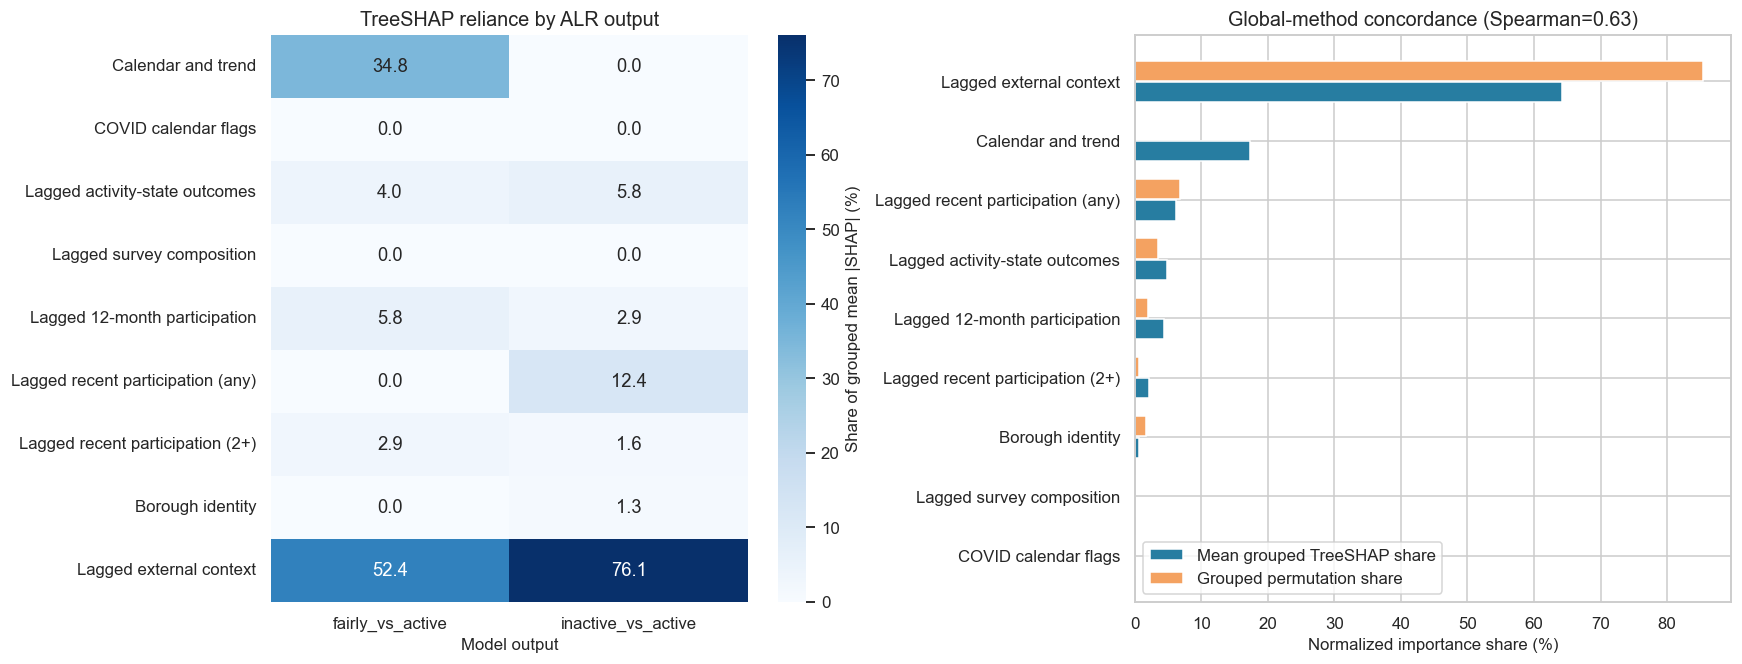

,predictor_group,mean_shap_importance_share,mean_increase,increase_relative_to_baseline,positive_permutation_increase,permutation_importance_share,shap_rank,permutation_rank,spearman_rank_correlation
5,Lagged external context,64.3%,0.0087,0.084279,0.008689,85.4%,1,1,0.63
2,Calendar and trend,17.4%,0.0000,0.000000,0.000000,0.0%,2,7,0.63
7,Lagged recent participation (any),6.2%,0.0007,0.006720,0.000693,6.8%,3,2,0.63
4,Lagged activity-state outcomes,4.9%,0.0004,0.003464,0.000357,3.5%,4,3,0.63
3,Lagged 12-month participation,4.4%,0.0002,0.001983,0.000204,2.0%,5,4,0.63
6,Lagged recent participation (2+),2.2%,0.0001,0.000604,0.000062,0.6%,6,6,0.63
0,Borough identity,0.7%,0.0002,0.001643,0.000169,1.7%,7,5,0.63
1,COVID calendar flags,0.0%,0.0000,0.000000,0.000000,0.0%,8,7,0.63
8,Lagged survey composition,0.0%,0.0000,0.000000,0.000000,0.0%,8,7,0.63


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.2))
heat = shap_group_importance.pivot(
    index='predictor_group', columns='output', values='importance_share_within_output'
).reindex(PREDICTOR_GROUPS)
sns.heatmap(
    100 * heat,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Share of grouped mean |SHAP| (%)'},
    ax=axes[0],
)
axes[0].set(title='TreeSHAP reliance by ALR output', xlabel='Model output', ylabel='')

comparison_plot = shap_permutation_concordance.sort_values('mean_shap_importance_share')
positions = np.arange(len(comparison_plot))
axes[1].barh(
    positions - 0.18,
    100 * comparison_plot['mean_shap_importance_share'],
    height=0.34,
    label='Mean grouped TreeSHAP share',
    color='#277da1',
)
axes[1].barh(
    positions + 0.18,
    100 * comparison_plot['permutation_importance_share'],
    height=0.34,
    label='Grouped permutation share',
    color='#f4a261',
)
axes[1].set_yticks(positions, comparison_plot['predictor_group'])
axes[1].set(
    title=f'Global-method concordance (Spearman={rank_correlation:.2f})',
    xlabel='Normalized importance share (%)',
    ylabel='',
)
axes[1].legend()
plt.tight_layout()
plt.show()
display(
    shap_permutation_concordance.sort_values('shap_rank').style.format(
        {
            'mean_shap_importance_share': '{:.1%}',
            'mean_increase': '{:.4f}',
            'permutation_importance_share': '{:.1%}',
            'spearman_rank_correlation': '{:.2f}',
            'shap_rank': '{:.0f}',
            'permutation_rank': '{:.0f}',
        }
    )
)


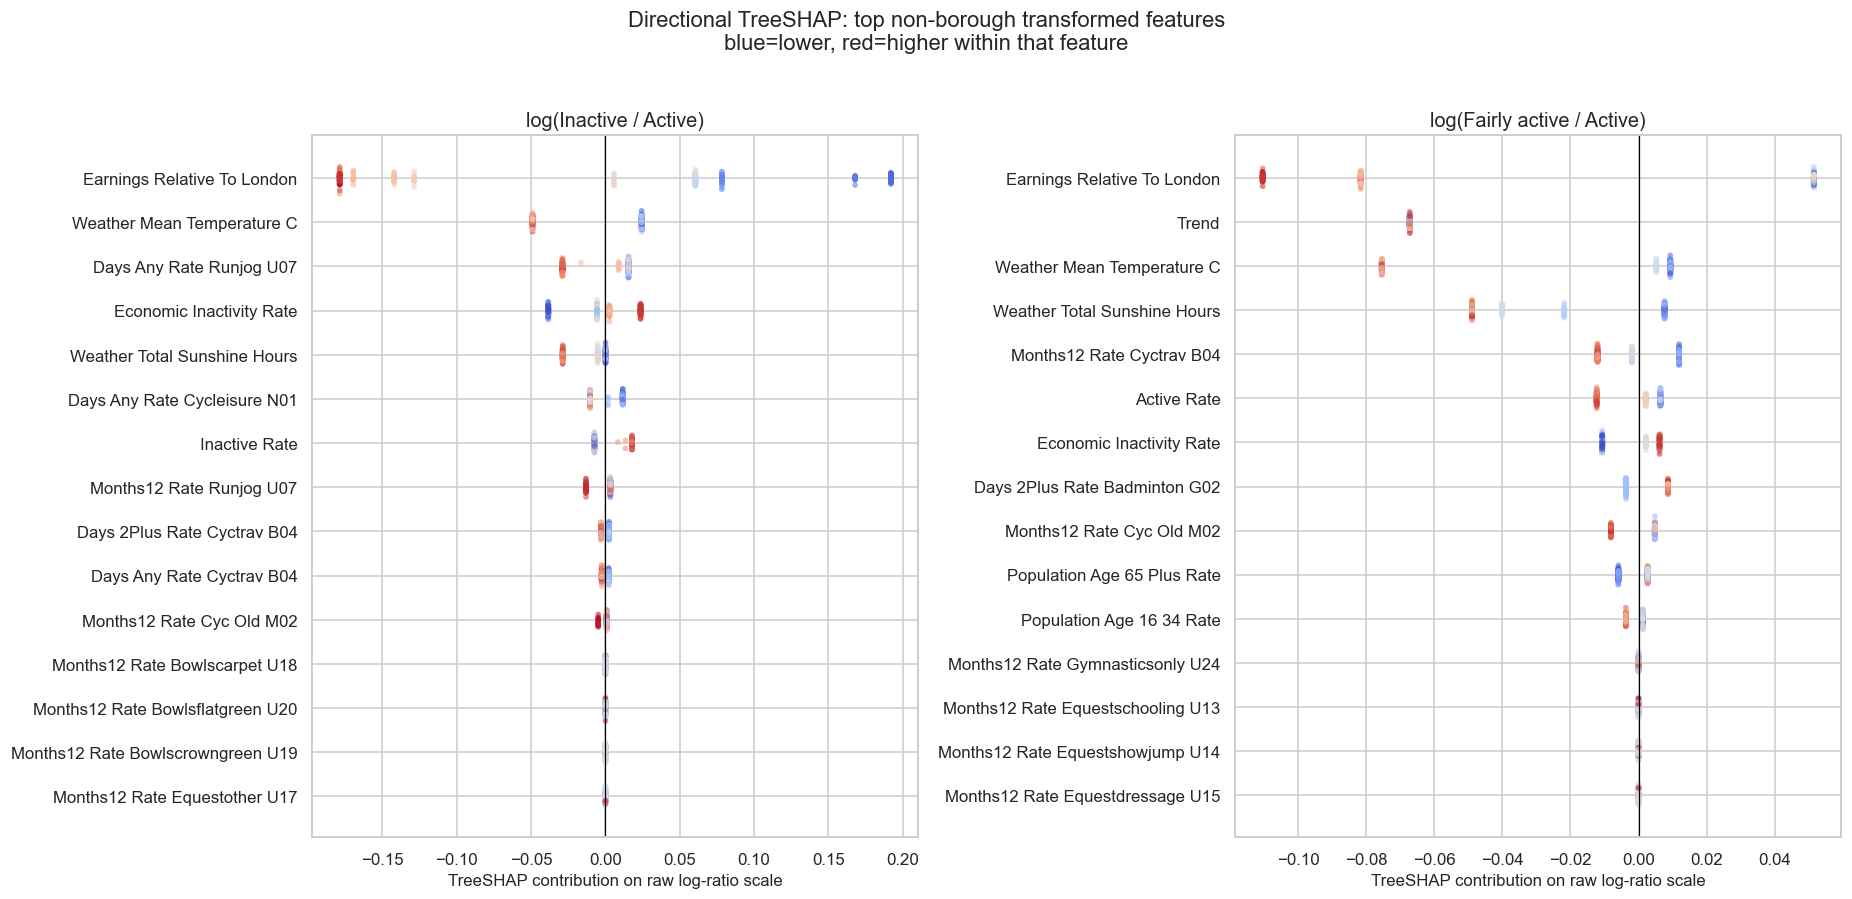

In [38]:
# Direction plots exclude individual borough one-hot fields; borough remains in group results.
non_borough_indices = np.flatnonzero(transformed_feature_groups != 'Borough identity')
fig, axes = plt.subplots(1, 2, figsize=(17, 8), sharex=False)
rng = np.random.default_rng(RANDOM_STATE)
for ax, (output_name, explanation) in zip(axes, tree_shap_explanations.items()):
    importance = np.abs(explanation.values[:, non_borough_indices]).mean(axis=0)
    top_local_positions = np.argsort(importance)[-15:]
    top_indices = non_borough_indices[top_local_positions]
    top_indices = top_indices[np.argsort(np.abs(explanation.values[:, top_indices]).mean(axis=0))]
    for y_position, feature_index in enumerate(top_indices):
        shap_values = explanation.values[:, feature_index]
        feature_values = X_holdout_transformed[:, feature_index]
        ranks = pd.Series(feature_values).rank(pct=True).to_numpy()
        jitter = rng.normal(0, 0.08, len(shap_values))
        ax.scatter(
            shap_values,
            y_position + jitter,
            c=ranks,
            cmap='coolwarm',
            vmin=0,
            vmax=1,
            s=14,
            alpha=0.58,
            linewidths=0,
        )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(range(len(top_indices)), [friendly_feature_names[i] for i in top_indices])
    ax.set(
        title=SHAP_OUTPUT_LABELS[output_name],
        xlabel='TreeSHAP contribution on raw log-ratio scale',
        ylabel='',
    )
plt.suptitle(
    'Directional TreeSHAP: top non-borough transformed features\nblue=lower, red=higher within that feature',
    y=1.02,
)
plt.tight_layout()
plt.show()


### Select auditable local cases

One median-error and one maximum-error borough-month are chosen using the frozen holdout predictions.


In [39]:
# Explain one typical and one difficult test prediction using signed group contributions.
holdout_case_summary = (
    holdout[['month_index', 'period_start', 'geography_code', 'geography_name', 'effective_n']]
    .reset_index(drop=True)
    .copy()
)
holdout_case_summary['total_variation_error'] = 0.5 * np.abs(
    actual_holdout - holdout_prediction
).sum(axis=1)
holdout_case_summary['actual_active_rate'] = actual_holdout[:, 2]
holdout_case_summary['predicted_active_rate'] = holdout_prediction[:, 2]
median_error = holdout_case_summary['total_variation_error'].median()
typical_index = (holdout_case_summary['total_variation_error'] - median_error).abs().idxmin()
difficult_index = holdout_case_summary['total_variation_error'].idxmax()
case_indices = {'Typical-error case': typical_index, 'Largest-error case': difficult_index}
local_case_rows = []
for case_label, row_index in case_indices.items():
    case_metadata = holdout_case_summary.loc[row_index].to_dict()
    for output_name, explanation in tree_shap_explanations.items():
        for group_name in PREDICTOR_GROUPS:
            feature_mask = transformed_feature_groups == group_name
            local_case_rows.append(
                {
                    'case': case_label,
                    **case_metadata,
                    'output': output_name,
                    'output_scale': SHAP_OUTPUT_LABELS[output_name],
                    'predictor_group': group_name,
                    'signed_group_shap': explanation.values[row_index, feature_mask].sum(),
                    'base_value': explanation.base_values[row_index],
                }
            )
monthly_shap_local_cases = pd.DataFrame(local_case_rows)
monthly_shap_local_cases.to_csv(
    OUTPUT_DIR / 'monthly_shap_local_cases.csv', index=False, encoding='utf-8-sig'
)


### Local signed group contributions

The plots retain the two ALR outputs and make the prediction-specific direction of each group explicit.


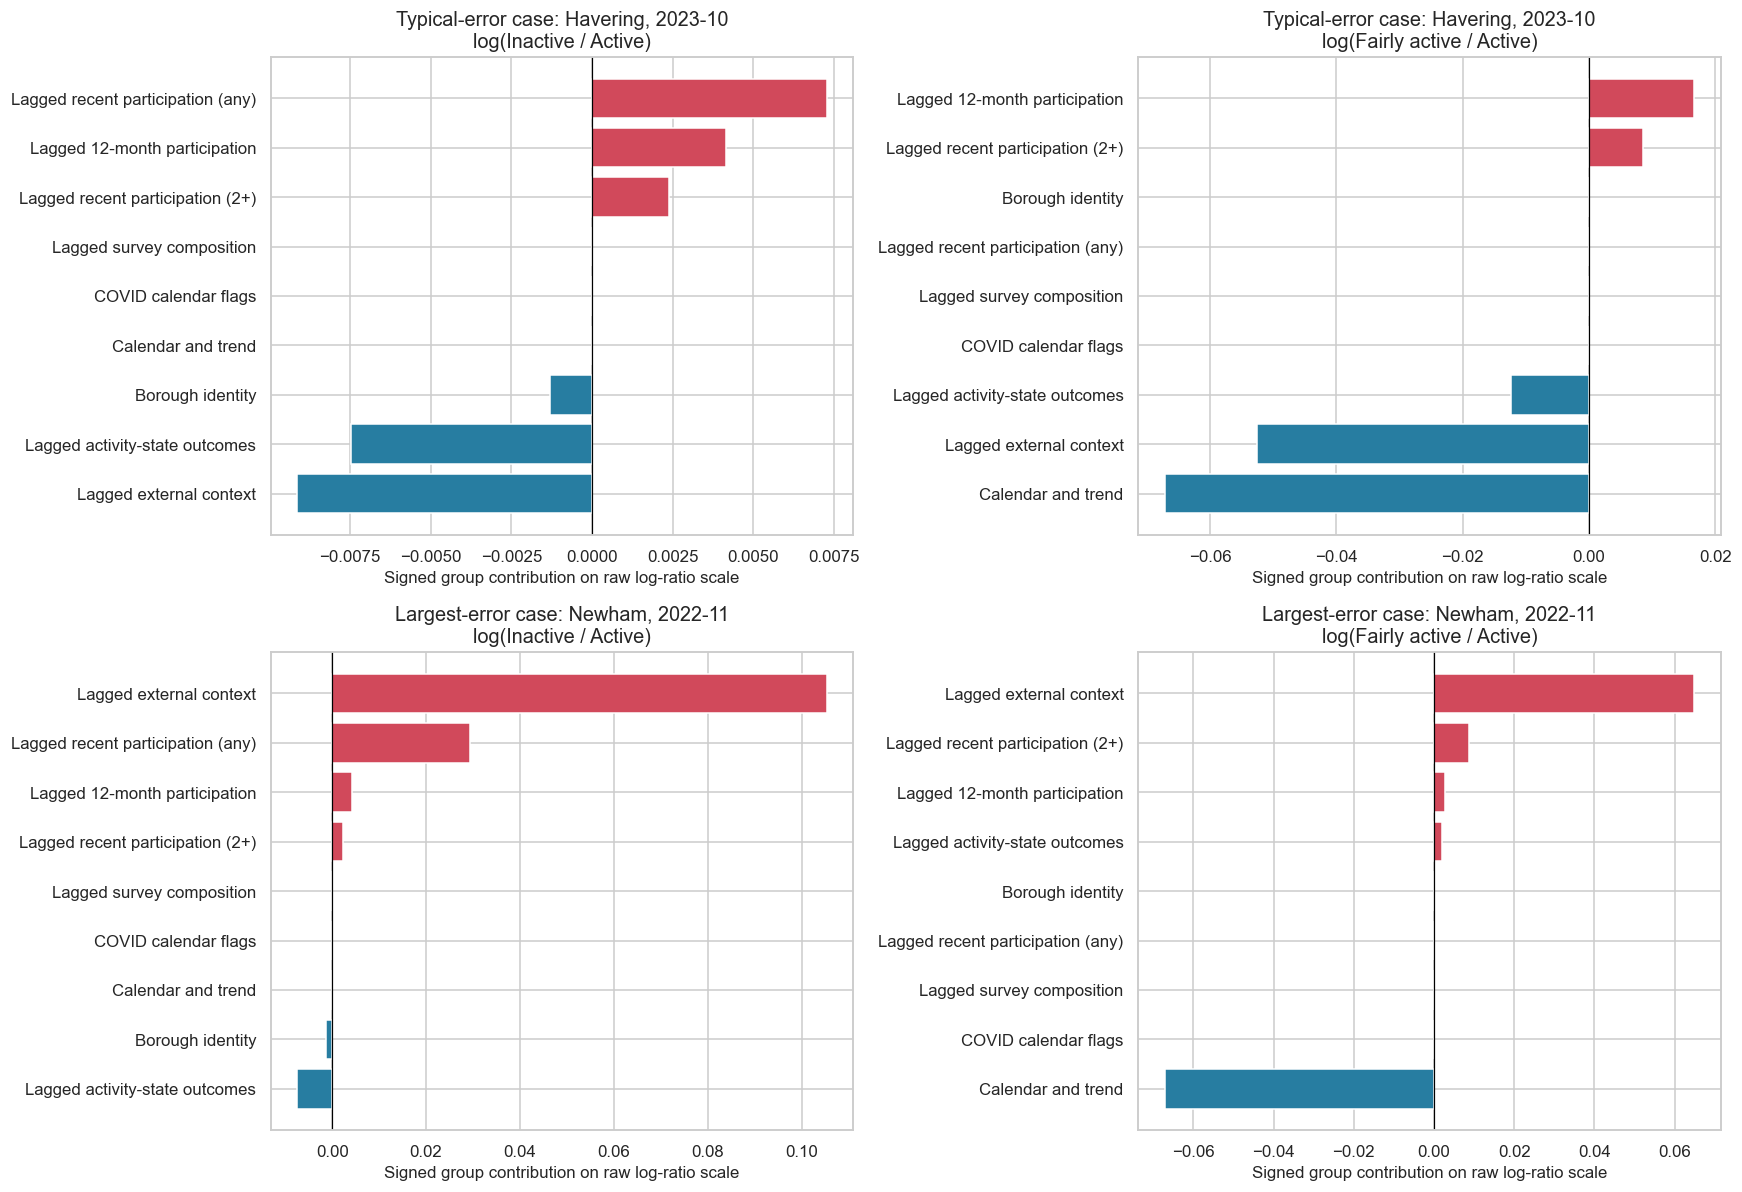

,month_index,period_start,geography_code,geography_name,effective_n,total_variation_error,actual_active_rate,predicted_active_rate
179,96,2023-10-01 00:00:00,E09000016,Havering,24.6,0.094,57.9%,67.3%
276,85,2022-11-01 00:00:00,E09000025,Newham,20.2,0.349,29.5%,64.3%


In [40]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for row_position, (case_label, row_index) in enumerate(case_indices.items()):
    for column_position, output_name in enumerate(SHAP_OUTPUT_LABELS):
        ax = axes[row_position, column_position]
        data = monthly_shap_local_cases.loc[
            monthly_shap_local_cases['case'].eq(case_label)
            & monthly_shap_local_cases['output'].eq(output_name)
        ].sort_values('signed_group_shap')
        colors_local = np.where(data['signed_group_shap'].ge(0), '#d1495b', '#277da1')
        ax.barh(data['predictor_group'], data['signed_group_shap'], color=colors_local)
        ax.axvline(0, color='black', linewidth=0.8)
        borough = holdout_case_summary.loc[row_index, 'geography_name']
        period = holdout_case_summary.loc[row_index, 'period_start'].strftime('%Y-%m')
        ax.set(
            title=f'{case_label}: {borough}, {period}\n{SHAP_OUTPUT_LABELS[output_name]}',
            xlabel='Signed group contribution on raw log-ratio scale',
            ylabel='',
        )
plt.tight_layout()
plt.show()
display(
    holdout_case_summary.loc[list(case_indices.values())].style.format(
        {
            'effective_n': '{:.1f}',
            'total_variation_error': '{:.3f}',
            'actual_active_rate': '{:.1%}',
            'predicted_active_rate': '{:.1%}',
        }
    )
)


In [41]:
# Check whether global group rankings depend on background size or dependence semantics.
shap_sensitivity_parts = []
for rows_per_borough in [2, 4, 8]:
    background = stratified_background(development, rows_per_borough)
    X_background = preprocessor.transform(background[model_features])
    explanations = {}
    for output_index, output_name in enumerate(SHAP_OUTPUT_LABELS):
        explainer = shap.TreeExplainer(
            tree_estimators[output_index],
            data=X_background,
            feature_perturbation='interventional',
            model_output='raw',
            feature_names=transformed_feature_names,
        )
        explanations[output_name] = explainer(X_holdout_transformed, check_additivity=True)
    summary, _ = summarise_group_shap(explanations, f'interventional_background_{len(background)}')
    shap_sensitivity_parts.append(summary)

path_explanations = {}
for output_index, output_name in enumerate(SHAP_OUTPUT_LABELS):
    explainer = shap.TreeExplainer(
        tree_estimators[output_index],
        data=None,
        feature_perturbation='tree_path_dependent',
        model_output='raw',
        feature_names=transformed_feature_names,
    )
    path_explanations[output_name] = explainer(X_holdout_transformed, check_additivity=True)
path_summary, _ = summarise_group_shap(path_explanations, 'tree_path_dependent')
shap_sensitivity_parts.append(path_summary)
shap_sensitivity = pd.concat(shap_sensitivity_parts, ignore_index=True)

baseline_sensitivity = shap_sensitivity.loc[
    shap_sensitivity['method'].eq('interventional_background_128')
]
sensitivity_rank_rows = []
for (method, output_name), group in shap_sensitivity.groupby(['method', 'output']):
    reference = baseline_sensitivity.loc[
        baseline_sensitivity['output'].eq(output_name),
        ['predictor_group', 'mean_absolute_group_shap'],
    ].rename(columns={'mean_absolute_group_shap': 'reference_importance'})
    comparison = group.merge(reference, on='predictor_group', validate='one_to_one')
    correlation = spearmanr(
        comparison['mean_absolute_group_shap'], comparison['reference_importance']
    ).statistic
    sensitivity_rank_rows.append(
        {
            'method': method,
            'output': output_name,
            'spearman_vs_interventional_background_128': correlation,
            'top_group': group.sort_values('mean_absolute_group_shap', ascending=False).iloc[0][
                'predictor_group'
            ],
        }
    )
shap_sensitivity_ranks = pd.DataFrame(sensitivity_rank_rows)
shap_sensitivity.to_csv(
    OUTPUT_DIR / 'monthly_shap_sensitivity_group_values.csv', index=False, encoding='utf-8-sig'
)
shap_sensitivity_ranks.to_csv(
    OUTPUT_DIR / 'monthly_shap_sensitivity_ranks.csv', index=False, encoding='utf-8-sig'
)
display(
    shap_sensitivity_ranks.style.format({'spearman_vs_interventional_background_128': '{:.2f}'})
)


,method,output,spearman_vs_interventional_background_128,top_group
0,interventional_background_128,fairly_vs_active,1.00,Lagged external context
1,interventional_background_128,inactive_vs_active,1.00,Lagged external context
2,interventional_background_256,fairly_vs_active,1.00,Lagged external context
3,interventional_background_256,inactive_vs_active,1.00,Lagged external context
4,interventional_background_64,fairly_vs_active,0.98,Calendar and trend
5,interventional_background_64,inactive_vs_active,1.00,Lagged external context
6,tree_path_dependent,fairly_vs_active,1.00,Lagged external context
7,tree_path_dependent,inactive_vs_active,1.00,Lagged external context


### What the three explanation layers show

- **Refit ablation:** removing lagged external context causes the largest deterioration after
  retraining, but the increase is only **+0.0022 TV** (**+2.1%** of baseline); other groups can
  substitute.
- **Grouped-permutation stress test:** globally shuffling the same block increases TV by **0.0087**
  (**8.4%** of baseline). This larger effect partly reflects unrealistic borough-time combinations
  and is not a confidence interval or real-world effect size.
- **TreeSHAP:** lagged external context dominates both ALR outputs for the main 128-row background.
  Calendar/trend becomes important for `log(Fairly active / Active)`. SHAP values operate on
  log-ratios, not percentage-point active-share effects.
- **Agreement and stability:** SHAP/permutation group-rank Spearman is **0.63**; SHAP sensitivity
  correlations are at least **0.98**. This supports the broad group story, not exact ranks among
  correlated individual variables.

All three layers explain the fitted predictor. None identifies a causal effect of borough identity,
COVID, an external condition or an activity type.


### Annual forecast transparency

Notebook 02 selected the annual model on Year 7 and did not change it after Year 8. Seasonal Naive
is fully transparent: each borough's next-year inactive, fairly-active and active shares equal its
previous-year shares. Complex models remain comparison benchmarks only.


In [42]:
annual_validation_metrics = pd.read_csv(
    PREDICTION_DIR / 'annual_forecast_validation_metrics.csv'
).sort_values('weighted_tv')
annual_test_metrics = pd.read_csv(PREDICTION_DIR / 'annual_forecast_test_metrics.csv').sort_values(
    'weighted_tv'
)
ANNUAL_SELECTED_MODEL = annual_validation_metrics.iloc[0]['model']
assert ANNUAL_SELECTED_MODEL == 'Seasonal naive'
annual_transparency = pd.DataFrame(
    [
        {
            'item': 'Selected model',
            'result': ANNUAL_SELECTED_MODEL,
            'interpretation': 'Chosen using Year 7 validation only',
        },
        {
            'item': 'Prediction rule',
            'result': 'Year t forecast = Year t−1 observed composition',
            'interpretation': 'No fitted coefficient or black-box mechanism',
        },
        {
            'item': 'Year 8 selected-model weighted TV',
            'result': annual_test_metrics.loc[
                annual_test_metrics['model'].eq(ANNUAL_SELECTED_MODEL), 'weighted_tv'
            ].iloc[0],
            'interpretation': 'Independent test result; not used for reselection',
        },
        {
            'item': 'Year 8 test winner',
            'result': annual_test_metrics.iloc[0]['model'],
            'interpretation': 'Reported as stability evidence, not substituted after testing',
        },
    ]
)
annual_transparency.to_csv(
    OUTPUT_DIR / 'annual_selected_model_transparency.csv', index=False, encoding='utf-8-sig'
)
display(annual_transparency)


,item,result,interpretation
0,Selected model,Seasonal naive,Chosen using Year 7 validation only
1,Prediction rule,Year t forecast = Year t−1 observed composition,No fitted coefficient or black-box mechanism
2,Year 8 selected-model weighted TV,0.04178,Independent test result; not used for reselection
3,Year 8 test winner,Ridge,"Reported as stability evidence, not substitute..."


### Finding

The frozen annual choice is Seasonal Naive: Year `t` equals the observed Year `t−1` composition.
Its transparency is complete, but the validation/test rank reversal in Notebook 02 means it should
be presented as a limited backtest rather than a stable forecasting rule.


## 8. Evidence hierarchy and final interpretation

The notebook deliberately separates three evidence levels:

1. **Exact for the reconstruction:** age composition versus within-age rates.
2. **Conditional and model-dependent:** cross-sectional and within-borough contextual associations.
3. **Predictive, not causal:** refit ablation, grouped permutation and TreeSHAP for the frozen model.

A named policy would require a justified intervention date, comparison group and identifying
assumptions. Those conditions are absent, so no policy or quasi-experimental effect is claimed.


In [43]:
top_cross = cross_coefficients.iloc[
    cross_coefficients['coefficient_pp_per_within_year_sd'].abs().argmax()
]
top_predictive_group = group_permutation.sort_values('mean_increase', ascending=False).iloc[0]
top_refit_group = refit_group_ablation.sort_values(
    'increase_in_weighted_tv', ascending=False
).iloc[0]
crime_wild_summary = crime_bootstrap[
    ['specification', 'coefficient', 'cluster_robust_p_value', 'wild_cluster_bootstrap_p_value']
].copy()
final_evidence = pd.DataFrame(
    [
        {
            'question': 'Are annual borough age-stratified results feasible?',
            'answer': 'Yes, with precision shown',
            'evidence': (
                f"{len(age_borough_annual):,} complete cells; "
                f"{age_borough_annual['effective_n'].lt(20).mean():.1%} below effective_n 20"
            ),
        },
        {
            'question': 'What is decomposed exactly?',
            'answer': 'The reconstructed age-group-weighted rate only',
            'evidence': (
                f"London Year 1→8: composition={london_endpoint_decomposition['composition_effect']:.2%}; "
                f"within-age behaviour={london_endpoint_decomposition['within_age_behaviour_effect']:.2%}"
            ),
        },
        {
            'question': 'What most strongly distinguishes boroughs in the full conditional model?',
            'answer': top_cross['feature'],
            'evidence': (
                f"{top_cross['coefficient_pp_per_within_year_sd']:.2f} pp per within-year SD; "
                f"cluster-robust 95% CI [{top_cross['ci_low']:.2f}, {top_cross['ci_high']:.2f}]"
            ),
        },
        {
            'question': 'Which input block most affects the selected monthly forecast?',
            'answer': top_predictive_group['predictor_group'],
            'evidence': f"Permutation increase={top_predictive_group['mean_increase']:.4f} "
            f"({top_predictive_group['increase_relative_to_baseline']:.1%} of baseline); "
            f"largest refit ablation={top_refit_group['removed_predictor_group']} "
            f"({top_refit_group['increase_in_weighted_tv']:+.4f})",
        },
        {
            'question': 'How is the selected nonlinear monthly model explained?',
            'answer': 'Held-out grouped permutation + interventional TreeSHAP',
            'evidence': (
                f'Maximum SHAP additivity error={shap_additivity_audit["maximum_additivity_error"].max():.2e}; '
                f'SHAP/permutation group-rank Spearman={rank_correlation:.2f}'
            ),
        },
        {
            'question': 'Can a particular policy effect be claimed?',
            'answer': 'No',
            'evidence': (
                'Policy is not separately identified; selected crime is explicitly classified as '
                f"specification-sensitive. Wild-bootstrap p-values span "
                f"{crime_wild_summary['wild_cluster_bootstrap_p_value'].min():.3f}–"
                f"{crime_wild_summary['wild_cluster_bootstrap_p_value'].max():.3f}."
            ),
        },
    ]
)
final_evidence.to_csv(
    OUTPUT_DIR / 'explanatory_final_evidence.csv', index=False, encoding='utf-8-sig'
)
display(final_evidence)

assert age_decomposition['identity_error'].abs().max() < 1e-12
assert np.allclose(holdout_prediction.sum(axis=1), 1, atol=1e-12)
assert group_permutation['mean_increase'].notna().all()
assert group_permutation[['randomisation_q025', 'randomisation_q975']].notna().all().all()
assert refit_group_ablation['increase_in_weighted_tv'].notna().all()
assert wild_cluster_results['wild_cluster_bootstrap_p_value'].between(0, 1).all()
assert shap_additivity_audit['maximum_additivity_error'].max() < 1e-7
assert shap_sensitivity_ranks['spearman_vs_interventional_background_128'].min() >= 0.9
assert monthly_shap_local_cases['case'].nunique() == 2
assert (
    cross_coefficients[['coefficient_pp_per_within_year_sd', 'ci_low', 'ci_high']]
    .notna()
    .all()
    .all()
)
assert trend_attribution[attribution_columns + ['observed_change_pp']].notna().all().all()


,question,answer,evidence
0,Are annual borough age-stratified results feas...,"Yes, with precision shown","1,024 complete cells; 0.4% below effective_n 20"
1,What is decomposed exactly?,The reconstructed age-group-weighted rate only,London Year 1→8: composition=-0.24%; within-ag...
2,What most strongly distinguishes boroughs in t...,earnings_relative_to_london,2.89 pp per within-year SD; cluster-robust 95%...
3,Which input block most affects the selected mo...,Lagged external context,Permutation increase=0.0087 (8.4% of baseline)...
4,How is the selected nonlinear monthly model ex...,Held-out grouped permutation + interventional ...,Maximum SHAP additivity error=2.48e-09; SHAP/p...
5,Can a particular policy effect be claimed?,No,Policy is not separately identified; selected ...


### Final findings

- Age-stratified annual estimation is feasible, and London’s reconstructed decade change is driven
  mainly by within-age rates rather than population ageing.
- Same-time borough contrasts are most consistently associated with relative earnings and economic
  inactivity, conditional on the stated model—not with migration or selected crime.
- Lagged external context is the most influential predictor group for the selected monthly model,
  but its structural refit contribution is modest and all explanations remain predictive.
- Selected crime is specification-sensitive, and no named policy effect is identified.
